<a href="https://colab.research.google.com/github/SvitLanaTy/HWDS/blob/main/Mammowave_Ripetibilita_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Mammowave — Analisi Ripetibilità
### Analisi completa delle 5 metriche per paziente e seno

**Struttura del notebook:**
1. Setup e mount Google Drive
2. Caricamento e pulizia dati (Passo 1)
3. Ripetibilità intra-sessione — CV% e ICC (Passo 2)
4. Ripetibilità inter-sessione (Passo 3)
5. Effetto coppa (Passo 4)
6. Analisi per paziente e seno (Passo 5)
7. Analisi dedicata `max2avg`
8. Grafici multi-metrica per paziente/seno
9. Export report su Google Drive

> **Come usare:** Esegui le celle nell'ordine. Ogni sezione è indipendente dopo la Sezione 2.


## 1. Setup — installazione librerie e mount Google Drive

In [ ]:
# Installazione librerie aggiuntive (scipy già presente in Colab)
!pip install openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, wilcoxon
import warnings
warnings.filterwarnings('ignore')

# Stile grafico globale
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print("✅ Librerie caricate correttamente")

✅ Librerie caricate correttamente


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print("✅ Google Drive montato")

Mounted at /content/drive
✅ Google Drive montato


In [ ]:
# ── PERCORSI FILE ──────────────────────────────────────────────────────────
FILE_PATH   = "/content/drive/MyDrive/data/rep/TEST-RIPETIBILITA_local_measurements.xlsx"
OUTPUT_DIR  = "/content/drive/MyDrive/data/rep/output"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"📂 Output directory: {OUTPUT_DIR}")

📂 Output directory: /content/drive/MyDrive/data/rep/output


## 2. Caricamento e pulizia dati (Passo 1)
Normalizzazione del campo `Mis.`, costruzione coppie intra-sessione, etichette di sessione e ruolo coppa.

In [ ]:
# ── CARICAMENTO ────────────────────────────────────────────────────────────
df = pd.read_excel(FILE_PATH)
print(f"📊 Dataset caricato: {df.shape[0]} righe × {df.shape[1]} colonne")
print(f"   Colonne: {list(df.columns)}")
df.head(3)

📊 Dataset caricato: 180 righe × 11 colonne
   Colonne: ['Patient', 'Fase', 'Breast', 'Mis.', 'Cup', 'Examination date', 'max_n', 'max2avg', 'var_p', 'mad_p', 'var_r']


,Patient,Fase,Breast,Mis.,Cup,Examination date,max_n,max2avg,var_p,mad_p,var_r
0,1000,1,LEFT,Tg.IV,II,2026-01-13 09:25:25.576,0.779476,2.586944,0.102585,0.242926,0.828048
1,1000,1,LEFT,Tg.IV,II,2026-01-13 09:14:26.110,0.577395,1.961391,0.029818,0.146383,0.264721
2,1000,1,RIGHT,Tg.IV,II,2026-01-13 09:03:25.598,0.885216,2.996218,0.174122,0.254043,1.301305


In [ ]:
# ── PULIZIA E NORMALIZZAZIONE ──────────────────────────────────────────────
METRICS = ['max_n', 'max2avg', 'var_p', 'mad_p', 'var_r']

# Normalizza taglia
mis_map = {
    'Tg II':'Tg.II', 'Tg. II':'Tg.II', 'Tg.II':'Tg.II',
    'Tg.IV':'Tg.IV', 'Tg. IV':'Tg.IV',
    'Tg.III':'Tg.III', 'Tg.III ':'Tg.III',
    'tg. IIIc':'Tg.IIIc',
}
df['Mis_norm'] = df['Mis.'].str.strip().map(lambda x: mis_map.get(x, x))

# Aggiungi colonne utili
df['Examination date'] = pd.to_datetime(df['Examination date'])
df = df.sort_values(['Patient','Fase','Breast','Examination date']).reset_index(drop=True)

pair_counts = df.groupby(['Patient','Fase','Breast']).size().reset_index(name='pair_count')
df = df.merge(pair_counts, on=['Patient','Fase','Breast'])
df['coppia_completa'] = df['pair_count'] == 2
df['Sessione']  = df['Fase'].apply(lambda x: 'A' if x % 2 == 1 else 'B')
df['Cup_Role']  = df['Fase'].map({1:'Base',2:'Base',3:'Base+1',4:'Base+1',
                                   5:'Base+2',6:'Base+2',7:'Extra'})
df['Acq_n'] = df.groupby(['Patient','Fase','Breast']).cumcount() + 1

# Riepilogo
n_complete   = (df['coppia_completa']).sum()
n_incomplete = (~df['coppia_completa']).sum()
print(f"✅ Pulizia completata")
print(f"   Acquisizioni totali   : {len(df)}")
print(f"   In coppie complete    : {n_complete} ({n_complete/len(df)*100:.0f}%)")
print(f"   In coppie incomplete  : {n_incomplete}")
print(f"\nDistribuzione taglie normalizzate:")
print(df['Mis_norm'].value_counts().to_string())

✅ Pulizia completata
   Acquisizioni totali   : 180
   In coppie complete    : 172 (96%)
   In coppie incomplete  : 8

Distribuzione taglie normalizzate:
Mis_norm
Tg.II      112
Tg.IV       36
Tg.III      16
Tg.IIIc     16


In [ ]:
# ── TABELLA RIEPILOGO PAZIENTI ─────────────────────────────────────────────
summary = []
for pat in sorted(df['Patient'].unique()):
    sub = df[df['Patient'] == pat]
    fasi = sorted(sub['Fase'].unique())
    cups = sub.groupby('Fase')['Cup'].first().to_dict()
    inc  = sub[~sub['coppia_completa']][['Fase','Breast']].drop_duplicates()
    summary.append({
        'Paziente': pat,
        'Taglia': sub['Mis_norm'].iloc[0],
        'Coppa base': sub[sub['Fase']==fasi[0]]['Cup'].iloc[0],
        'N fasi': len(fasi),
        'N acquisizioni': len(sub),
        'N coppie complete': sub['coppia_completa'].sum() // 2,  # diviso 2 = coppie
        'Coppie incomplete': len(inc),
        'Coppe utilizzate': ', '.join(sub['Cup'].unique()),
    })

df_summary = pd.DataFrame(summary)
print("📋 Riepilogo per paziente:")
display(df_summary)

📋 Riepilogo per paziente:


,Paziente,Taglia,Coppa base,N fasi,N acquisizioni,N coppie complete,Coppie incomplete,Coppe utilizzate
0,1000,Tg.IV,II,7,24,10,4,"II, III, III teflon"
1,2000,Tg.II,I,6,24,12,0,"I, II, III teflon"
2,3000,Tg.IV,III,4,12,4,4,"III, III teflon"
3,4000,Tg.III,II,4,16,8,0,"II, III"
4,5000,Tg.II,I,6,24,12,0,"I, II, III teflon"
5,6000,Tg.II,I,6,24,12,0,"I, II, III teflon"
6,7000,Tg.IIIc,II,4,16,8,0,"II, III"
7,8000,Tg.II,I,6,24,12,0,"I, II, III teflon"
8,9000,Tg.II,I,4,16,8,0,"I, II"


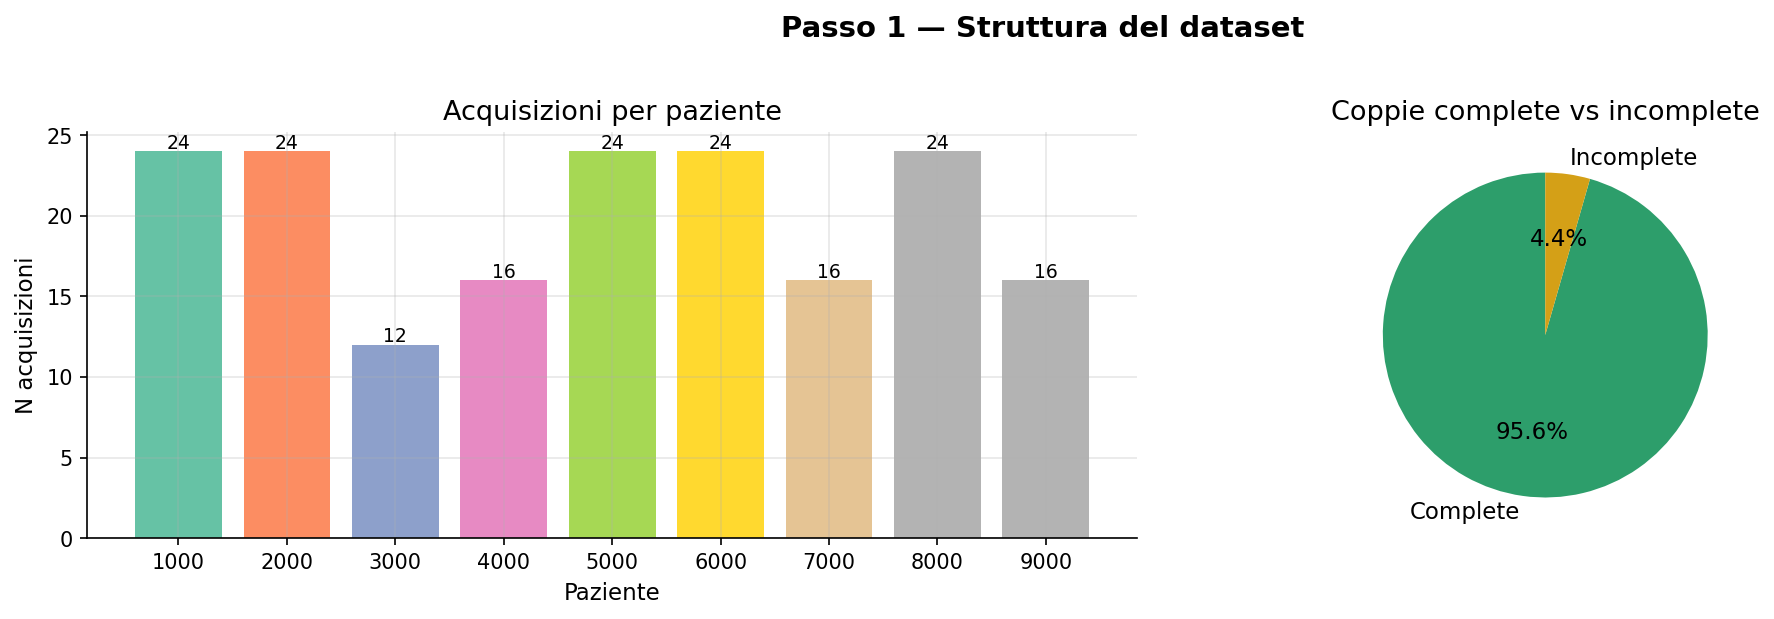

💾 Salvato: passo1_struttura_dataset.png


In [ ]:
# ── GRAFICO: distribuzione acquisizioni per paziente e seno ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Acquisizioni per paziente
acq_counts = df.groupby('Patient').size()
colors_pat = plt.cm.Set2(np.linspace(0, 1, len(acq_counts)))
axes[0].bar([str(p) for p in acq_counts.index], acq_counts.values, color=colors_pat)
axes[0].set_title("Acquisizioni per paziente")
axes[0].set_xlabel("Paziente")
axes[0].set_ylabel("N acquisizioni")
for i, v in enumerate(acq_counts.values):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontsize=9)

# Coppie complete vs incomplete
labels_ = ['Complete', 'Incomplete']
vals_   = [df['coppia_completa'].sum(), (~df['coppia_completa']).sum()]
colors_ = ['#2d9e6b', '#d4a017']
wedges, texts, autotexts = axes[1].pie(vals_, labels=labels_, colors=colors_,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title("Coppie complete vs incomplete")

plt.suptitle("Passo 1 — Struttura del dataset", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/passo1_struttura_dataset.png")
plt.show()
print("💾 Salvato: passo1_struttura_dataset.png")

## 3. Ripetibilità intra-sessione (Passo 2)
Calcolo CV% e ICC tra le 2 acquisizioni consecutive della stessa sessione (senza spostare la paziente).

In [ ]:
# ── COSTRUZIONE DATASET COPPIE ─────────────────────────────────────────────
df_complete = df[df['coppia_completa']].copy()

acq1 = df_complete[df_complete['Acq_n']==1].set_index(['Patient','Fase','Breast'])
acq2 = df_complete[df_complete['Acq_n']==2].set_index(['Patient','Fase','Breast'])

pairs = acq1[METRICS].join(acq2[METRICS], lsuffix='_1', rsuffix='_2')
pairs = pairs.join(acq1[['Cup','Cup_Role','Sessione','Mis_norm']])
pairs = pairs.reset_index()

# CV% e differenza assoluta per ogni metrica
for m in METRICS:
    mean_ = (pairs[f'{m}_1'] + pairs[f'{m}_2']) / 2
    diff_ = (pairs[f'{m}_1'] - pairs[f'{m}_2']).abs()
    pairs[f'{m}_cv']      = (diff_ / mean_) * 100
    pairs[f'{m}_mean']    = mean_
    pairs[f'{m}_absdiff'] = diff_

print(f"✅ Dataset coppie costruito: {len(pairs)} coppie complete")
pairs[['Patient','Fase','Breast','Cup','max_n_mean','max_n_cv','max2avg_mean','max2avg_cv']].head(8)

✅ Dataset coppie costruito: 86 coppie complete


,Patient,Fase,Breast,Cup,max_n_mean,max_n_cv,max2avg_mean,max2avg_cv
0,1000,1,LEFT,II,0.678435,29.786374,2.274167,27.506880
1,1000,1,RIGHT,II,0.891146,1.330976,2.868699,8.890379
2,1000,2,LEFT,II,0.578447,41.863051,2.108000,10.946524
3,1000,2,RIGHT,II,0.728594,8.848637,2.466015,4.896803
4,1000,3,LEFT,III,0.735189,42.909184,2.742852,36.162047
5,1000,3,RIGHT,III,0.979560,10.082532,2.106565,2.266689
6,1000,5,LEFT,III teflon,0.749313,14.966835,2.288860,23.211294
7,1000,5,RIGHT,III teflon,0.785848,9.873062,2.871209,28.844164


In [ ]:
# ── FUNZIONE ICC (2,1) ─────────────────────────────────────────────────────
def icc_21(x1, x2):
    """ICC two-way mixed, consistency."""
    x1, x2 = np.array(x1, dtype=float), np.array(x2, dtype=float)
    n = len(x1)
    if n < 3:
        return np.nan
    data = np.stack([x1, x2], axis=1)
    grand_mean = data.mean()
    row_means  = data.mean(axis=1)
    col_means  = data.mean(axis=0)
    SSe = np.sum((data - row_means[:,None] - col_means[None,:] + grand_mean)**2)
    MS_e = SSe / ((n-1) * 1)
    MS_r = (np.sum((row_means - grand_mean)**2) * 2) / (n-1)
    MS_c = n * np.var(col_means, ddof=0)
    icc  = (MS_r - MS_e) / (MS_r + MS_e + 2*(MS_c - MS_e)/n)
    return round(float(icc), 3)

def icc_label(v):
    if np.isnan(v):  return '—'
    if v >= 0.90:    return f'{v:.3f} ★★★'
    if v >= 0.75:    return f'{v:.3f} ★★'
    if v >= 0.50:    return f'{v:.3f} ★'
    return f'{v:.3f} ✗'

print("✅ Funzione ICC definita")
print("   ★★★ ≥ 0.90 eccellente | ★★ 0.75–0.89 buono | ★ 0.50–0.74 moderato | ✗ < 0.50 scarso")

✅ Funzione ICC definita
   ★★★ ≥ 0.90 eccellente | ★★ 0.75–0.89 buono | ★ 0.50–0.74 moderato | ✗ < 0.50 scarso


In [ ]:
# ── TABELLA RIEPILOGO INTRA-SESSIONE ──────────────────────────────────────
rows = []
for m in METRICS:
    icc_g = icc_21(pairs[f'{m}_1'], pairs[f'{m}_2'])
    icc_l = icc_21(pairs[pairs['Breast']=='LEFT'][f'{m}_1'],
                   pairs[pairs['Breast']=='LEFT'][f'{m}_2'])
    icc_r = icc_21(pairs[pairs['Breast']=='RIGHT'][f'{m}_1'],
                   pairs[pairs['Breast']=='RIGHT'][f'{m}_2'])
    cv    = pairs[f'{m}_cv']
    rows.append({
        'Metrica'    : m,
        'ICC globale': icc_g,
        'ICC LEFT'   : icc_l,
        'ICC RIGHT'  : icc_r,
        'CV% medio'  : round(cv.mean(), 2),
        'CV% mediana': round(cv.median(), 2),
        'CV%<10%'    : f"{(cv<10).mean()*100:.1f}%",
        'CV%<15%'    : f"{(cv<15).mean()*100:.1f}%",
    })

df_intra = pd.DataFrame(rows)

# Formattazione colorata
def color_icc(val):
    try:
        v = float(str(val).split()[0])
        if v >= 0.90: return 'background-color: #c6efce'
        if v >= 0.75: return 'background-color: #bdd7ee'
        if v >= 0.50: return 'background-color: #ffeb9c'
        return 'background-color: #ffc7ce'
    except: return ''

def color_cv(val):
    try:
        v = float(str(val).replace('%',''))
        if v < 10:  return 'background-color: #c6efce'
        if v < 15:  return 'background-color: #ffeb9c'
        if v < 25:  return 'background-color: #fce4d6'
        return 'background-color: #ffc7ce'
    except: return ''

print("📋 Tabella ripetibilità intra-sessione (86 coppie):")
styled = (df_intra.style
    .applymap(color_icc, subset=['ICC globale','ICC LEFT','ICC RIGHT'])
    .applymap(color_cv,  subset=['CV% medio','CV% mediana'])
    .set_caption("Ripetibilità intra-sessione — ICC e CV% per metrica"))
display(styled)
df_intra.to_csv(f"{OUTPUT_DIR}/passo2_intra_globale.csv", index=False)
print("💾 Salvato: passo2_intra_globale.csv")

📋 Tabella ripetibilità intra-sessione (86 coppie):


,Metrica,ICC globale,ICC LEFT,ICC RIGHT,CV% medio,CV% mediana,CV%<10%,CV%<15%
0,max_n,0.921000,0.862000,0.968000,11.430000,6.770000,62.8%,77.9%
1,max2avg,0.668000,0.563000,0.775000,7.870000,6.240000,75.6%,84.9%
2,var_p,0.411000,0.230000,0.585000,53.280000,46.570000,11.6%,22.1%
3,mad_p,0.495000,0.365000,0.620000,30.830000,25.880000,19.8%,27.9%
4,var_r,0.373000,0.215000,0.563000,56.030000,49.840000,11.6%,16.3%


💾 Salvato: passo2_intra_globale.csv


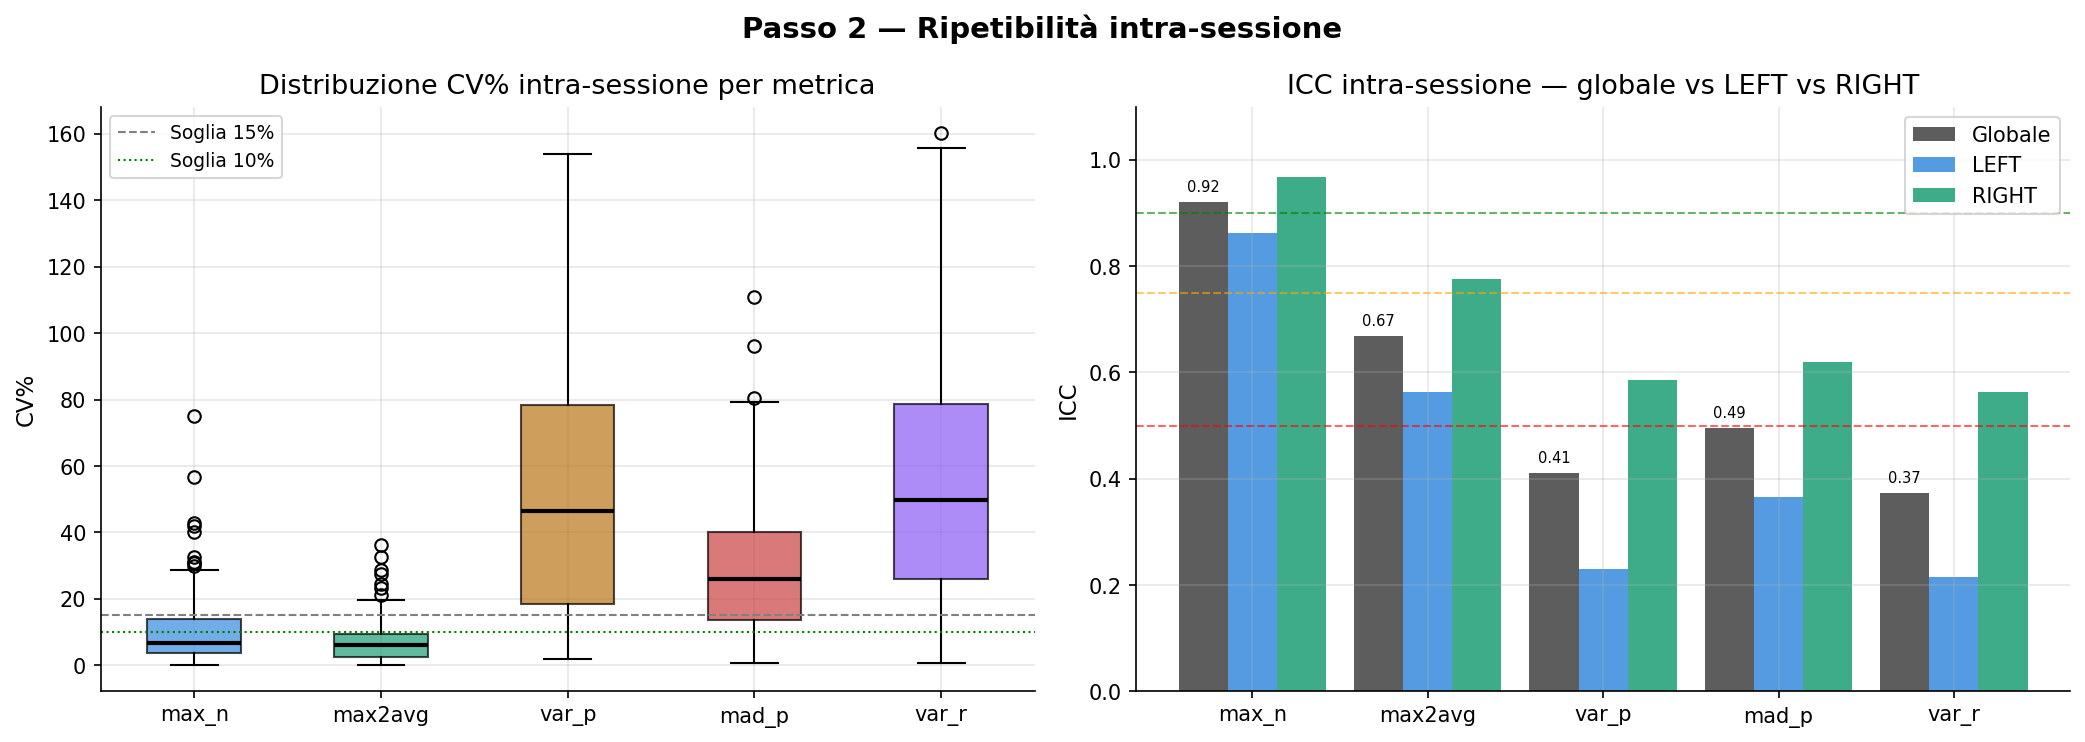

💾 Salvato: passo2_intra_cv_icc.png


In [ ]:
# ── GRAFICO 1: CV% intra per metrica ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_m = {'max_n':'#378ADD','max2avg':'#1D9E75','var_p':'#BA7517','mad_p':'#c94040','var_r':'#8b5cf6'}

# Box plot CV% per metrica
cv_data  = [pairs[f'{m}_cv'].values for m in METRICS]
bp = axes[0].boxplot(cv_data, labels=METRICS, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, m in zip(bp['boxes'], METRICS):
    patch.set_facecolor(colors_m[m])
    patch.set_alpha(0.7)
axes[0].axhline(15, color='gray', linestyle='--', linewidth=1, label='Soglia 15%')
axes[0].axhline(10, color='green', linestyle=':', linewidth=1, label='Soglia 10%')
axes[0].set_title("Distribuzione CV% intra-sessione per metrica")
axes[0].set_ylabel("CV%")
axes[0].legend(fontsize=9)

# ICC per metrica (globale, LEFT, RIGHT)
x = np.arange(len(METRICS))
w = 0.28
icc_g = [icc_21(pairs[f'{m}_1'], pairs[f'{m}_2']) for m in METRICS]
icc_l = [icc_21(pairs[pairs['Breast']=='LEFT'][f'{m}_1'],
                 pairs[pairs['Breast']=='LEFT'][f'{m}_2']) for m in METRICS]
icc_r = [icc_21(pairs[pairs['Breast']=='RIGHT'][f'{m}_1'],
                 pairs[pairs['Breast']=='RIGHT'][f'{m}_2']) for m in METRICS]

axes[1].bar(x - w,   icc_g, w, label='Globale', color='#404040', alpha=0.85)
axes[1].bar(x,       icc_l, w, label='LEFT',    color='#378ADD', alpha=0.85)
axes[1].bar(x + w,   icc_r, w, label='RIGHT',   color='#1D9E75', alpha=0.85)
axes[1].axhline(0.90, color='green',  linestyle='--', linewidth=1, alpha=0.6)
axes[1].axhline(0.75, color='orange', linestyle='--', linewidth=1, alpha=0.6)
axes[1].axhline(0.50, color='red',    linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(METRICS)
axes[1].set_title("ICC intra-sessione — globale vs LEFT vs RIGHT")
axes[1].set_ylabel("ICC")
axes[1].set_ylim(0, 1.1)
axes[1].legend()
for xi, v in zip(x - w, icc_g):
    if not np.isnan(v): axes[1].text(xi, v+0.02, f'{v:.2f}', ha='center', fontsize=7)

plt.suptitle("Passo 2 — Ripetibilità intra-sessione", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/passo2_intra_cv_icc.png")
plt.show()
print("💾 Salvato: passo2_intra_cv_icc.png")

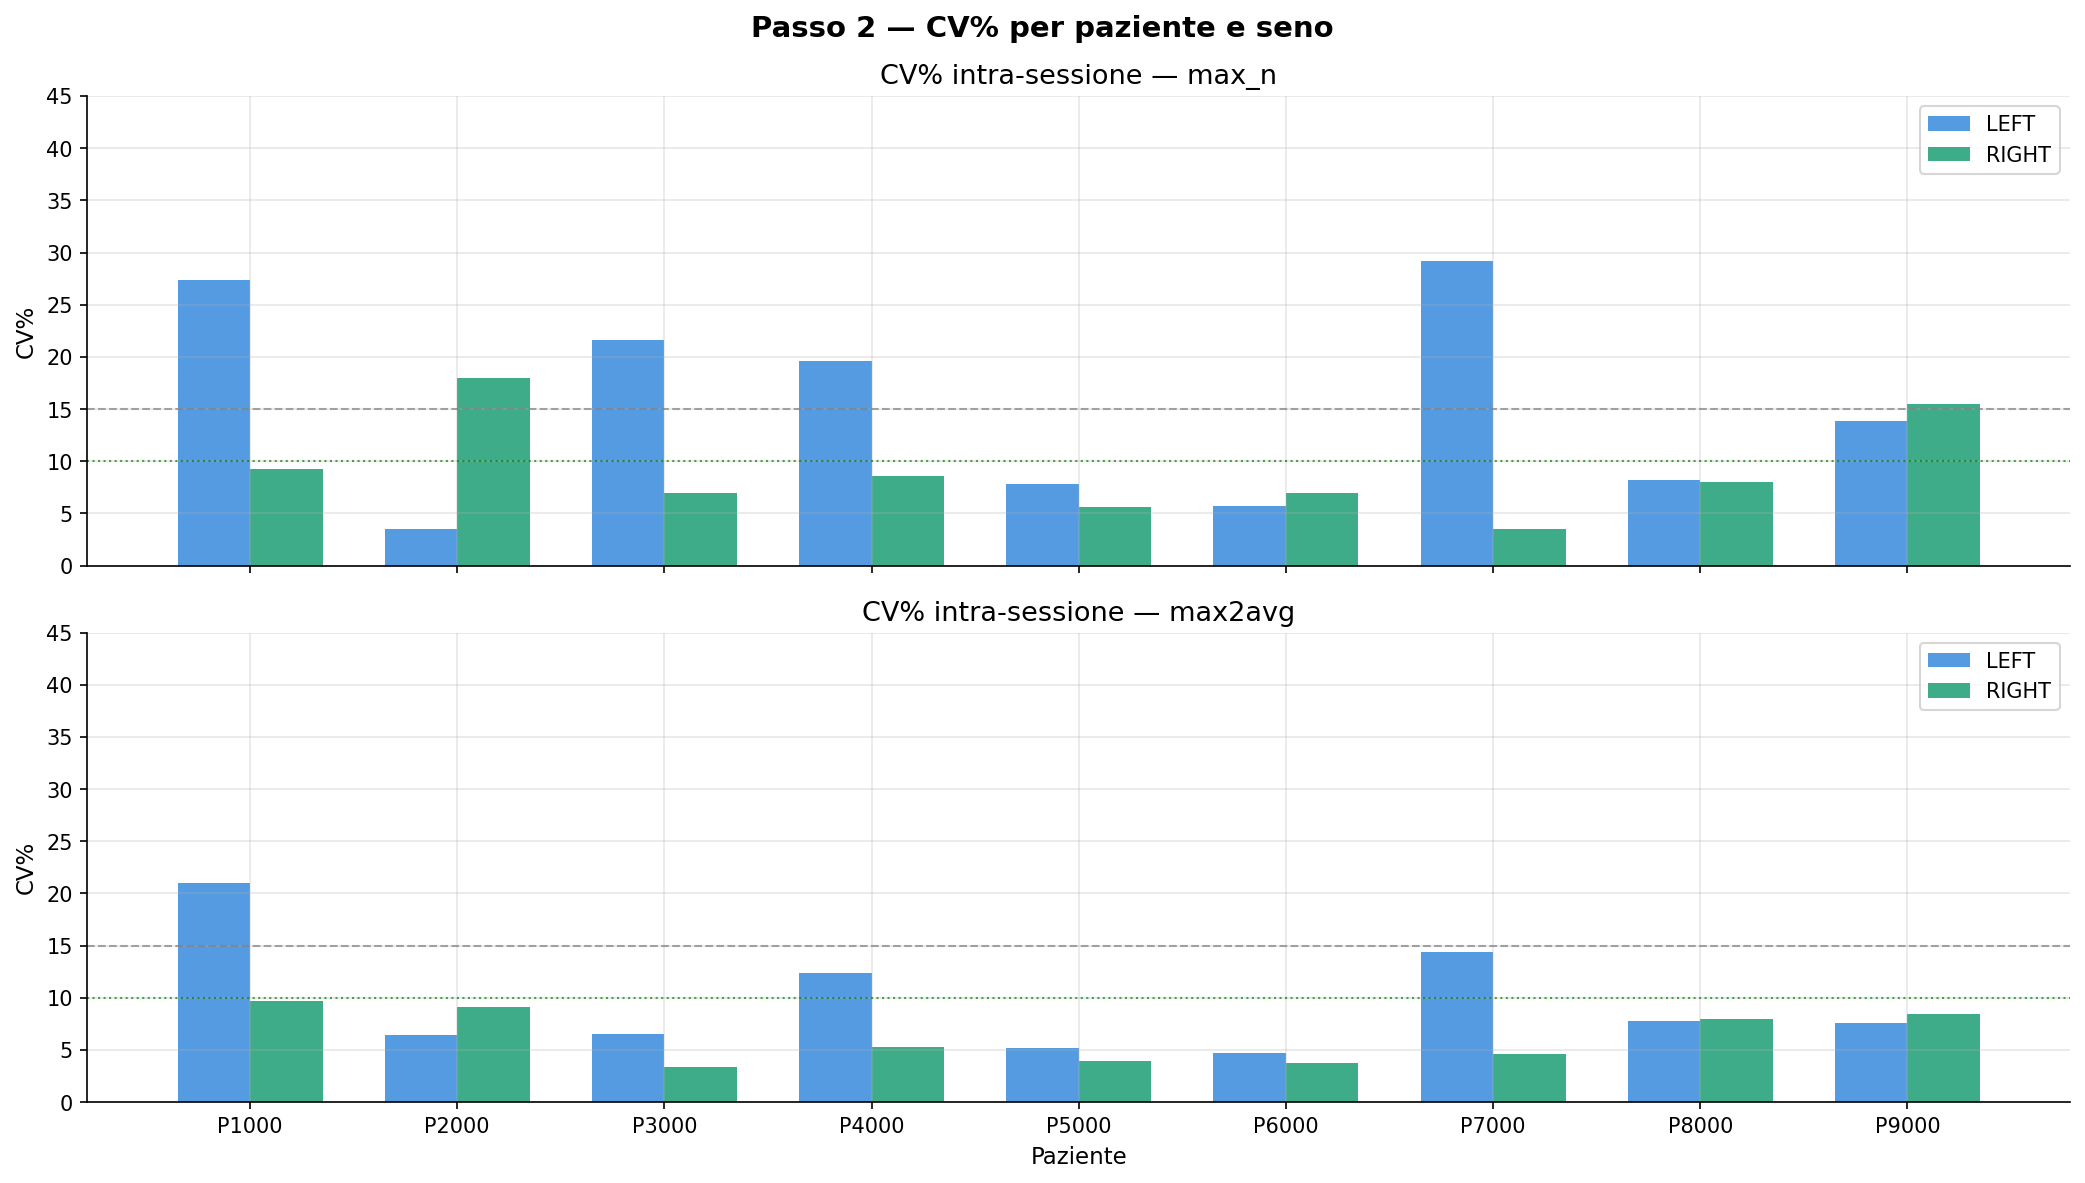

💾 Salvato: passo2_cv_per_paziente.png


In [ ]:
# ── GRAFICO 2: CV% per paziente e seno (max_n e max2avg) ──────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

patients = sorted(pairs['Patient'].unique())
x = np.arange(len(patients))
w = 0.35

for ax_idx, (metric, title) in enumerate([('max_n', 'max_n'), ('max2avg', 'max2avg')]):
    cv_l = [pairs[(pairs['Patient']==p)&(pairs['Breast']=='LEFT')][f'{metric}_cv'].mean()
            for p in patients]
    cv_r = [pairs[(pairs['Patient']==p)&(pairs['Breast']=='RIGHT')][f'{metric}_cv'].mean()
            for p in patients]

    axes[ax_idx].bar(x - w/2, cv_l, w, label='LEFT',  color='#378ADD', alpha=0.85)
    axes[ax_idx].bar(x + w/2, cv_r, w, label='RIGHT', color='#1D9E75', alpha=0.85)
    axes[ax_idx].axhline(15, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    axes[ax_idx].axhline(10, color='green', linestyle=':', linewidth=1, alpha=0.7)
    axes[ax_idx].set_title(f"CV% intra-sessione — {title}")
    axes[ax_idx].set_ylabel("CV%")
    axes[ax_idx].legend()
    axes[ax_idx].set_ylim(0, 45)

axes[1].set_xticks(x)
axes[1].set_xticklabels([f'P{p}' for p in patients])
axes[1].set_xlabel("Paziente")
plt.suptitle("Passo 2 — CV% per paziente e seno", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/passo2_cv_per_paziente.png")
plt.show()
print("💾 Salvato: passo2_cv_per_paziente.png")

## 4. Ripetibilità inter-sessione (Passo 3)
Confronto Sessione A (fasi dispari) vs Sessione B (fasi pari) — stessa coppa, riposizionamento dopo 30 min.

In [ ]:
# ── COSTRUZIONE DATASET INTER-SESSIONE ────────────────────────────────────
for m in METRICS:
    pairs[f'{m}_mean'] = (pairs[f'{m}_1'] + pairs[f'{m}_2']) / 2

mean_cols = [f'{m}_mean' for m in METRICS]

sessA = pairs[pairs['Sessione']=='A'].set_index(['Patient','Breast','Cup_Role'])
sessB = pairs[pairs['Sessione']=='B'].set_index(['Patient','Breast','Cup_Role'])

inter = (sessA[mean_cols + ['Cup','Mis_norm']]
         .join(sessB[mean_cols], lsuffix='_A', rsuffix='_B')
         .reset_index())

inter_clean = inter.dropna(subset=[f'{m}_mean_A' for m in METRICS] +
                                   [f'{m}_mean_B' for m in METRICS]).copy()

for m in METRICS:
    A = inter_clean[f'{m}_mean_A']
    B = inter_clean[f'{m}_mean_B']
    inter_clean[f'{m}_icv'] = ((A - B).abs() / ((A + B) / 2) * 100)

print(f"✅ Dataset inter-sessione: {len(inter_clean)} coppie A↔B complete")
inter_clean[['Patient','Breast','Cup_Role','max_n_icv','max2avg_icv']].head(8)

✅ Dataset inter-sessione: 42 coppie A↔B complete


,Patient,Breast,Cup_Role,max_n_icv,max2avg_icv
0,1000,LEFT,Base,15.910507,7.583804
1,1000,RIGHT,Base,20.071370,15.096739
4,1000,LEFT,Base+2,23.725335,2.849366
5,1000,RIGHT,Base+2,20.128085,14.934259
6,2000,LEFT,Base,10.292652,13.195015
7,2000,RIGHT,Base,6.025531,5.704682
8,2000,LEFT,Base+1,19.747927,2.660547
9,2000,RIGHT,Base+1,23.215596,0.897317


In [ ]:
# ── TABELLA CONFRONTO INTRA vs INTER ─────────────────────────────────────
rows_inter = []
for m in METRICS:
    A   = inter_clean[f'{m}_mean_A']
    B   = inter_clean[f'{m}_mean_B']
    icv = inter_clean[f'{m}_icv']
    icc_intra_ = icc_21(pairs[f'{m}_1'], pairs[f'{m}_2'])
    icc_inter_ = icc_21(A, B)
    cv_intra_  = pairs[f'{m}_cv'].mean()
    cv_inter_  = icv.mean()
    rows_inter.append({
        'Metrica'       : m,
        'ICC intra'     : round(icc_intra_, 3),
        'ICC inter'     : round(icc_inter_, 3),
        'CV% intra'     : round(cv_intra_, 2),
        'CV% inter'     : round(cv_inter_, 2),
        'Ratio inter/intra': round(cv_inter_ / cv_intra_, 2),
    })

df_inter = pd.DataFrame(rows_inter)
print("📋 Confronto intra vs inter-sessione:")
styled_inter = (df_inter.style
    .applymap(color_icc, subset=['ICC intra','ICC inter'])
    .applymap(color_cv,  subset=['CV% intra','CV% inter'])
    .background_gradient(subset=['Ratio inter/intra'], cmap='RdYlGn_r', vmin=1, vmax=3)
    .set_caption("Confronto intra vs inter-sessione — impatto del riposizionamento"))
display(styled_inter)
df_inter.to_csv(f"{OUTPUT_DIR}/passo3_inter_vs_intra.csv", index=False)
print("💾 Salvato: passo3_inter_vs_intra.csv")

📋 Confronto intra vs inter-sessione:


,Metrica,ICC intra,ICC inter,CV% intra,CV% inter,Ratio inter/intra
0,max_n,0.921000,0.871000,11.430000,21.250000,1.860000
1,max2avg,0.668000,0.524000,7.870000,9.790000,1.240000
2,var_p,0.411000,0.284000,53.280000,57.740000,1.080000
3,mad_p,0.495000,0.265000,30.830000,33.790000,1.100000
4,var_r,0.373000,0.205000,56.030000,58.810000,1.050000


💾 Salvato: passo3_inter_vs_intra.csv


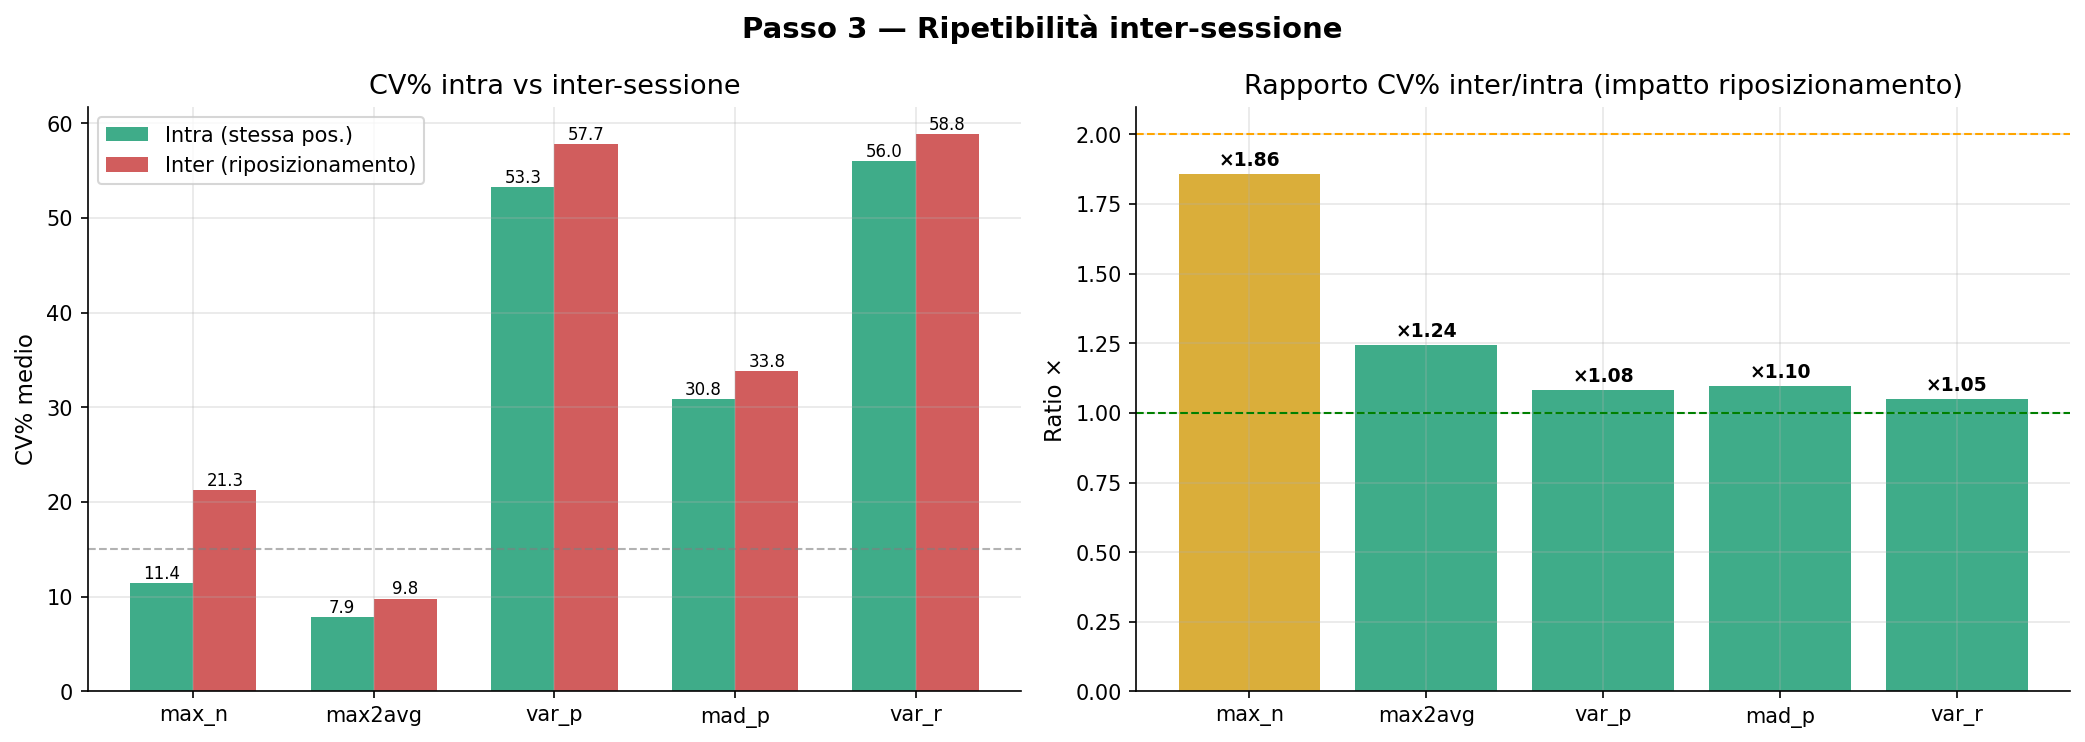

💾 Salvato: passo3_inter_sessione.png


In [ ]:
# ── GRAFICO: confronto intra vs inter per metrica ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mLabels = METRICS
x = np.arange(len(mLabels))
w = 0.35

cv_intra_vals = [pairs[f'{m}_cv'].mean() for m in METRICS]
cv_inter_vals = [inter_clean[f'{m}_icv'].mean() for m in METRICS]

bars1 = axes[0].bar(x - w/2, cv_intra_vals, w, label='Intra (stessa pos.)',
                    color='#1D9E75', alpha=0.85)
bars2 = axes[0].bar(x + w/2, cv_inter_vals, w, label='Inter (riposizionamento)',
                    color='#c94040', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(mLabels)
axes[0].set_title("CV% intra vs inter-sessione")
axes[0].set_ylabel("CV% medio")
axes[0].legend()
axes[0].axhline(15, color='gray', linestyle='--', linewidth=1, alpha=0.6)
for b1, b2, v1, v2 in zip(bars1, bars2, cv_intra_vals, cv_inter_vals):
    axes[0].text(b1.get_x()+b1.get_width()/2, v1+0.5, f'{v1:.1f}', ha='center', fontsize=8)
    axes[0].text(b2.get_x()+b2.get_width()/2, v2+0.5, f'{v2:.1f}', ha='center', fontsize=8)

# Ratio
ratios = [v2/v1 for v1, v2 in zip(cv_intra_vals, cv_inter_vals)]
bar_colors = ['#1D9E75' if r < 1.5 else '#d4a017' if r < 2.0 else '#c94040' for r in ratios]
bars_r = axes[1].bar(mLabels, ratios, color=bar_colors, alpha=0.85)
axes[1].axhline(1.0, color='green',  linestyle='--', linewidth=1)
axes[1].axhline(2.0, color='orange', linestyle='--', linewidth=1)
axes[1].set_title("Rapporto CV% inter/intra (impatto riposizionamento)")
axes[1].set_ylabel("Ratio ×")
for bar, v in zip(bars_r, ratios):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.03, f'×{v:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle("Passo 3 — Ripetibilità inter-sessione", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/passo3_inter_sessione.png")
plt.show()
print("💾 Salvato: passo3_inter_sessione.png")

## 5. Effetto coppa (Passo 4)
La coppa utilizzata influenza sistematicamente i valori misurati?

In [ ]:
# ── STATISTICHE PER COPPA ─────────────────────────────────────────────────
cups_order = ['I', 'II', 'III', 'III teflon']
cup_stats = []
for cup in cups_order:
    sub = pairs[pairs['Cup'] == cup]
    for m in METRICS:
        cup_stats.append({
            'Coppa': cup, 'Metrica': m, 'N': len(sub),
            'Media'  : round(sub[f'{m}_mean'].mean(), 4),
            'Mediana': round(sub[f'{m}_mean'].median(), 4),
            'Std'    : round(sub[f'{m}_mean'].std(), 4),
            'CV%_med': round(sub[f'{m}_cv'].mean(), 2),
            'ICC'    : icc_21(sub[f'{m}_1'], sub[f'{m}_2']),
        })

df_cup = pd.DataFrame(cup_stats)
print("📋 Statistiche per coppa (max_n e max2avg):")
display(df_cup[df_cup['Metrica'].isin(['max_n','max2avg'])]
        .style.applymap(color_icc, subset=['ICC'])
              .applymap(color_cv,  subset=['CV%_med'])
              .set_caption("Effetto coppa su max_n e max2avg"))
df_cup.to_csv(f"{OUTPUT_DIR}/passo4_effetto_coppa.csv", index=False)

📋 Statistiche per coppa (max_n e max2avg):


,Coppa,Metrica,N,Media,Mediana,Std,CV%_med,ICC
0,I,max_n,20,0.256400,0.254900,0.070700,10.650000,0.859000
1,I,max2avg,20,2.053700,2.087400,0.234800,7.850000,0.702000
5,II,max_n,32,0.348400,0.333600,0.174300,11.580000,0.903000
6,II,max2avg,32,2.106300,2.115700,0.252600,7.510000,0.668000
10,III,max_n,14,0.615300,0.556300,0.197800,18.040000,0.746000
11,III,max2avg,14,2.345400,2.290800,0.257700,10.450000,0.305000
15,III teflon,max_n,20,0.381000,0.309100,0.224800,7.360000,0.975000
16,III teflon,max2avg,20,2.113900,2.111300,0.333500,6.640000,0.770000


In [ ]:
# ── TEST STATISTICI KRUSKAL-WALLIS ────────────────────────────────────────
print("📊 Kruskal-Wallis test — effetto coppa per metrica:")
kw_results = []
for m in METRICS:
    groups = [pairs[pairs['Cup']==cup][f'{m}_mean'].values for cup in cups_order]
    H, p = kruskal(*groups)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    kw_results.append({'Metrica': m, 'H': round(H,3), 'p-value': round(p,5), 'Sig.': sig})

df_kw = pd.DataFrame(kw_results)
display(df_kw.style.applymap(
    lambda v: 'color: green; font-weight: bold' if v in ['***','**','*'] else 'color: gray',
    subset=['Sig.']).set_caption("Kruskal-Wallis: effetto coppa"))

# Mann-Whitney pairwise per max_n
print("\n📊 Mann-Whitney pairwise — max_n:")
from itertools import combinations
pw = []
for c1, c2 in combinations(cups_order, 2):
    a = pairs[pairs['Cup']==c1]['max_n_mean'].values
    b = pairs[pairs['Cup']==c2]['max_n_mean'].values
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    pw.append({'Coppa A': c1, 'Coppa B': c2, 'p-value': round(p,4),
               'Sig.': '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'})
display(pd.DataFrame(pw))

📊 Kruskal-Wallis test — effetto coppa per metrica:


,Metrica,H,p-value,Sig.
0,max_n,24.554000,0.000020,***
1,max2avg,8.796000,0.032130,*
2,var_p,8.044000,0.045110,*
3,mad_p,6.967000,0.072960,ns
4,var_r,6.500000,0.089670,ns



📊 Mann-Whitney pairwise — max_n:


,Coppa A,Coppa B,p-value,Sig.
0,I,II,0.0328,*
1,I,III,0.0000,***
2,I,III teflon,0.1075,ns
3,II,III,0.0001,***
4,II,III teflon,0.9176,ns
5,III,III teflon,0.0022,**


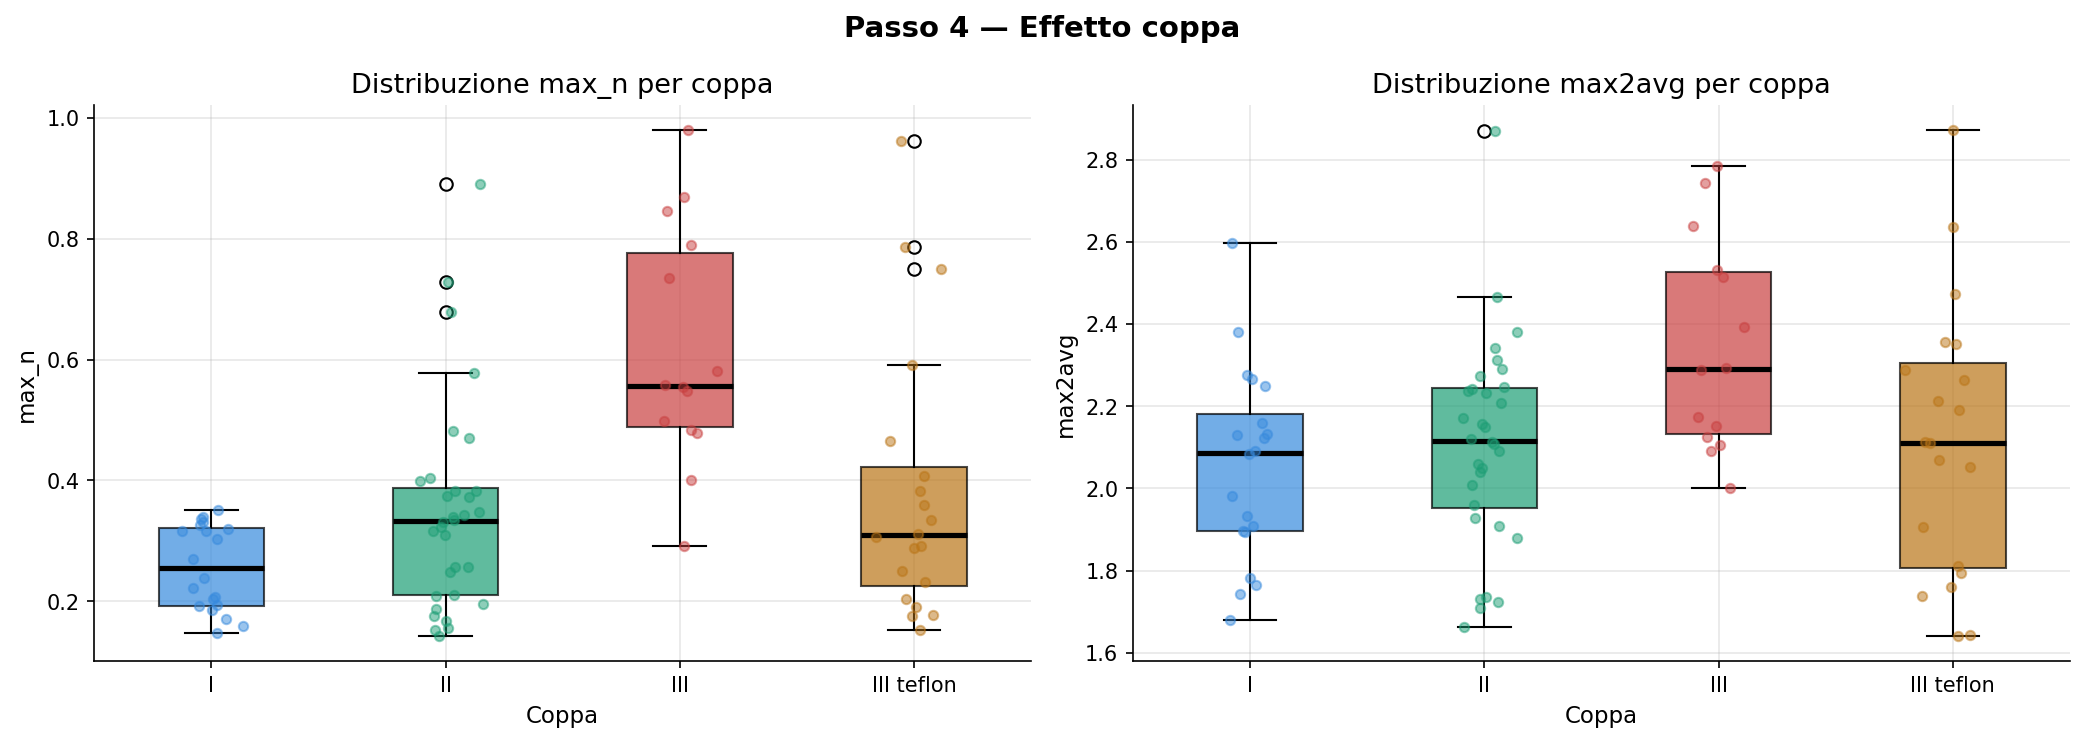

💾 Salvato: passo4_effetto_coppa.png


In [ ]:
# ── GRAFICI EFFETTO COPPA ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cup_colors = {'I':'#378ADD','II':'#1D9E75','III':'#c94040','III teflon':'#BA7517'}

for ax_idx, metric in enumerate(['max_n', 'max2avg']):
    data_by_cup = [pairs[pairs['Cup']==cup][f'{metric}_mean'].values for cup in cups_order]
    bp = axes[ax_idx].boxplot(data_by_cup, labels=cups_order, patch_artist=True,
                               medianprops=dict(color='black', linewidth=2.5))
    for patch, cup in zip(bp['boxes'], cups_order):
        patch.set_facecolor(cup_colors[cup])
        patch.set_alpha(0.7)
    # Scatter overlay
    for i, (cup, data) in enumerate(zip(cups_order, data_by_cup), 1):
        x_jitter = np.random.normal(i, 0.06, size=len(data))
        axes[ax_idx].scatter(x_jitter, data, alpha=0.5, s=20,
                             color=cup_colors[cup], zorder=3)
    axes[ax_idx].set_title(f"Distribuzione {metric} per coppa")
    axes[ax_idx].set_xlabel("Coppa")
    axes[ax_idx].set_ylabel(metric)

plt.suptitle("Passo 4 — Effetto coppa", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/passo4_effetto_coppa.png")
plt.show()
print("💾 Salvato: passo4_effetto_coppa.png")

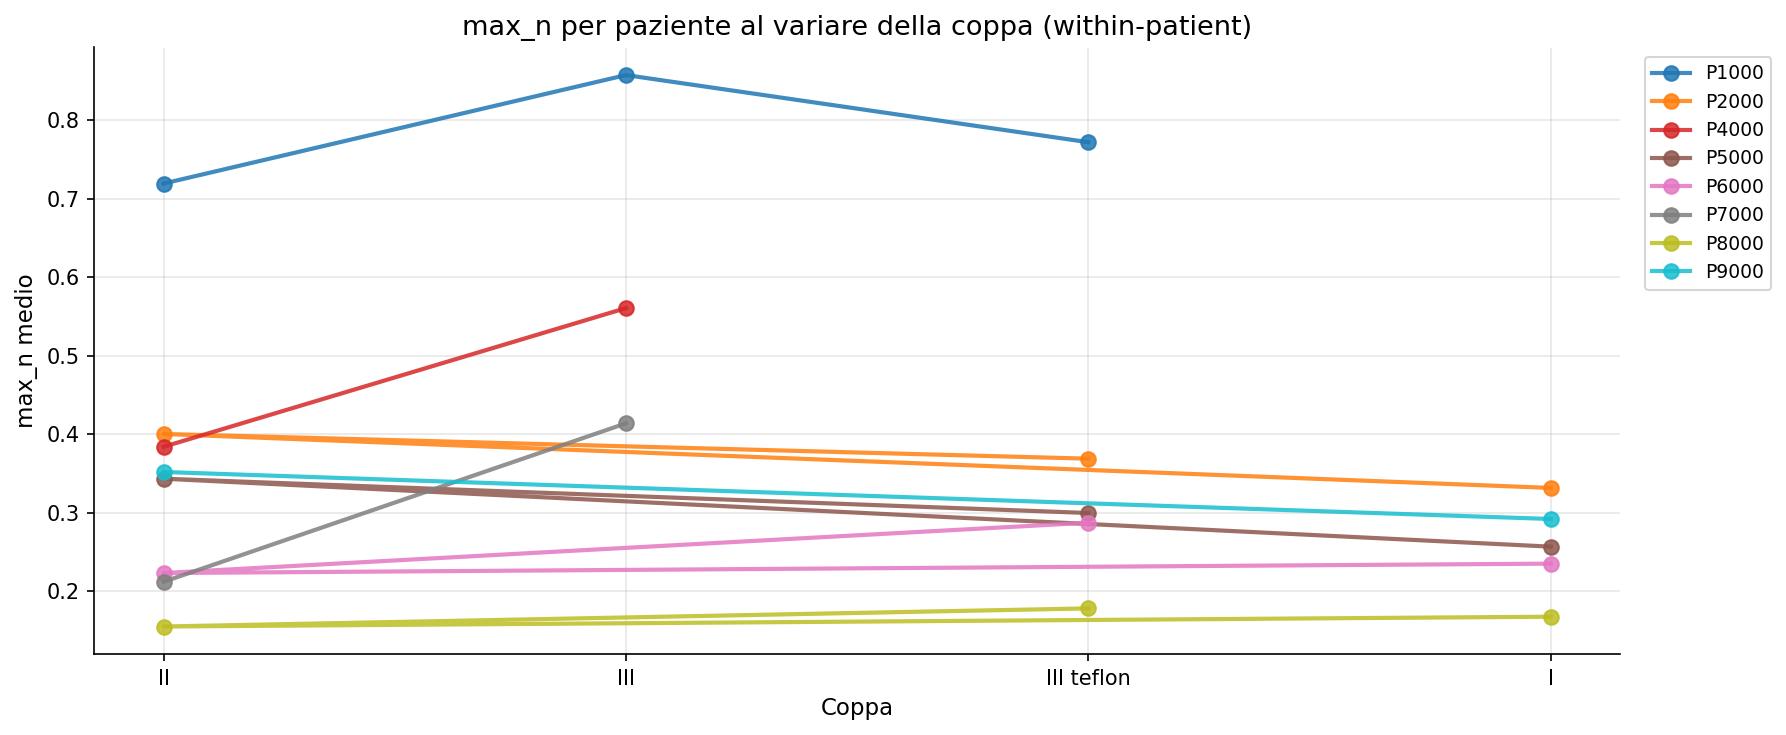

💾 Salvato: passo4_within_patient_cup.png


In [ ]:
# ── GRAFICO: max_n per paziente al variare della coppa (within-patient) ──
fig, ax = plt.subplots(figsize=(12, 5))

pat_colors = plt.cm.tab10(np.linspace(0, 1, len(patients)))

for pat, col in zip(patients, pat_colors):
    sub = pairs[pairs['Patient']==pat].groupby('Cup')[f'max_n_mean'].mean()
    ordered = sub.reindex(cups_order).dropna()
    if len(ordered) >= 2:
        ax.plot(ordered.index, ordered.values, 'o-', color=col,
                linewidth=2, markersize=7, label=f'P{pat}', alpha=0.85)

ax.set_title("max_n per paziente al variare della coppa (within-patient)")
ax.set_xlabel("Coppa")
ax.set_ylabel("max_n medio")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/passo4_within_patient_cup.png")
plt.show()
print("💾 Salvato: passo4_within_patient_cup.png")

## 6. Analisi per paziente e seno (Passo 5)
Profilo individuale, asimmetria LEFT/RIGHT, correlazione con taglia.

In [ ]:
# ── ETA² — CAPACITÀ DISCRIMINANTE ────────────────────────────────────────
print("📊 Capacità discriminante delle metriche (eta-squared):")
eta2_results = []
for m in METRICS:
    groups    = [df[df['Patient']==p][m].values for p in sorted(df['Patient'].unique())]
    grand_mn  = df[m].mean()
    SS_between= sum(len(g)*(g.mean()-grand_mn)**2 for g in groups)
    SS_total  = sum((v-grand_mn)**2 for g in groups for v in g)
    eta2      = SS_between / SS_total
    H, p      = kruskal(*groups)
    eta2_results.append({'Metrica': m, 'η²': round(eta2,3),
                         'Varianza paziente': f"{eta2*100:.1f}%",
                         'H statistic': round(H,1), 'p-value': round(p,5),
                         'Sig.': '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'})
df_eta2 = pd.DataFrame(eta2_results).sort_values('η²', ascending=False)

display(df_eta2.style
    .background_gradient(subset=['η²'], cmap='Greens', vmin=0, vmax=1)
    .set_caption("Capacità discriminante: % varianza spiegata dall'identità paziente"))
df_eta2.to_csv(f"{OUTPUT_DIR}/passo5_discriminabilita.csv", index=False)

📊 Capacità discriminante delle metriche (eta-squared):


,Metrica,η²,Varianza paziente,H statistic,p-value,Sig.
0,max_n,0.801000,80.1%,138.100000,0.000000,***
1,max2avg,0.453000,45.3%,85.200000,0.000000,***
3,mad_p,0.300000,30.0%,62.900000,0.000000,***
2,var_p,0.240000,24.0%,65.900000,0.000000,***
4,var_r,0.199000,19.9%,54.200000,0.000000,***


In [ ]:
# ── PROFILO PER PAZIENTE E SENO ───────────────────────────────────────────
taglia_map = {'Tg.II':2,'Tg.III':3,'Tg.IIIc':3.5,'Tg.IV':4}
profile_rows = []
for pat in sorted(df['Patient'].unique()):
    for breast in ['LEFT','RIGHT']:
        sub = df[(df['Patient']==pat) & (df['Breast']==breast)]
        if len(sub) == 0: continue
        row = {'Paziente':pat,'Seno':breast,'N':len(sub),'Taglia':sub['Mis_norm'].iloc[0]}
        for m in METRICS:
            v = sub[m].values
            row[f'{m}_mean'] = round(v.mean(), 4)
            row[f'{m}_std']  = round(v.std(), 4)
            row[f'{m}_cv']   = round(v.std()/v.mean()*100 if v.mean()!=0 else np.nan, 2)
        profile_rows.append(row)

df_profile = pd.DataFrame(profile_rows)

# Asimmetria per paziente
asym_rows = []
for pat in sorted(df['Patient'].unique()):
    lrow = df_profile[(df_profile['Paziente']==pat)&(df_profile['Seno']=='LEFT')].iloc[0]
    rrow = df_profile[(df_profile['Paziente']==pat)&(df_profile['Seno']=='RIGHT')].iloc[0]
    arow = {'Paziente':pat,'Taglia':lrow['Taglia']}
    for m in METRICS:
        l, r = lrow[f'{m}_mean'], rrow[f'{m}_mean']
        arow[f'{m}_delta%'] = round((l-r)/((l+r)/2)*100, 2)
    asym_rows.append(arow)
df_asym = pd.DataFrame(asym_rows)

print("📋 Profilo per paziente e seno:")
display(df_profile[['Paziente','Seno','Taglia','N','max_n_mean','max_n_cv','max2avg_mean','max2avg_cv']]
        .style.applymap(color_cv, subset=['max_n_cv','max2avg_cv'])
        .set_caption("Profilo per paziente/seno — max_n e max2avg"))

df_profile.to_csv(f"{OUTPUT_DIR}/passo5_profilo_paziente_seno.csv", index=False)
df_asym.to_csv(f"{OUTPUT_DIR}/passo5_asimmetria.csv", index=False)
print("💾 Salvati: passo5_profilo_paziente_seno.csv, passo5_asimmetria.csv")

📋 Profilo per paziente e seno:


,Paziente,Seno,Taglia,N,max_n_mean,max_n_cv,max2avg_mean,max2avg_cv
0,1000,LEFT,Tg.IV,12,0.671300,20.310000,2.333800,15.070000
1,1000,RIGHT,Tg.IV,12,0.877600,13.980000,2.545200,12.570000
2,2000,LEFT,Tg.II,12,0.375400,13.570000,2.309900,10.430000
3,2000,RIGHT,Tg.II,12,0.358100,22.040000,2.257500,8.230000
4,3000,LEFT,Tg.IV,6,0.743800,21.550000,2.194000,8.980000
5,3000,RIGHT,Tg.IV,6,0.698900,21.530000,2.477200,11.240000
6,4000,LEFT,Tg.III,8,0.458700,24.750000,2.219300,10.620000
7,4000,RIGHT,Tg.III,8,0.485600,19.570000,2.325800,6.880000
8,5000,LEFT,Tg.II,12,0.268000,22.820000,1.971600,10.280000
9,5000,RIGHT,Tg.II,12,0.331500,16.970000,2.078200,9.110000


💾 Salvati: passo5_profilo_paziente_seno.csv, passo5_asimmetria.csv


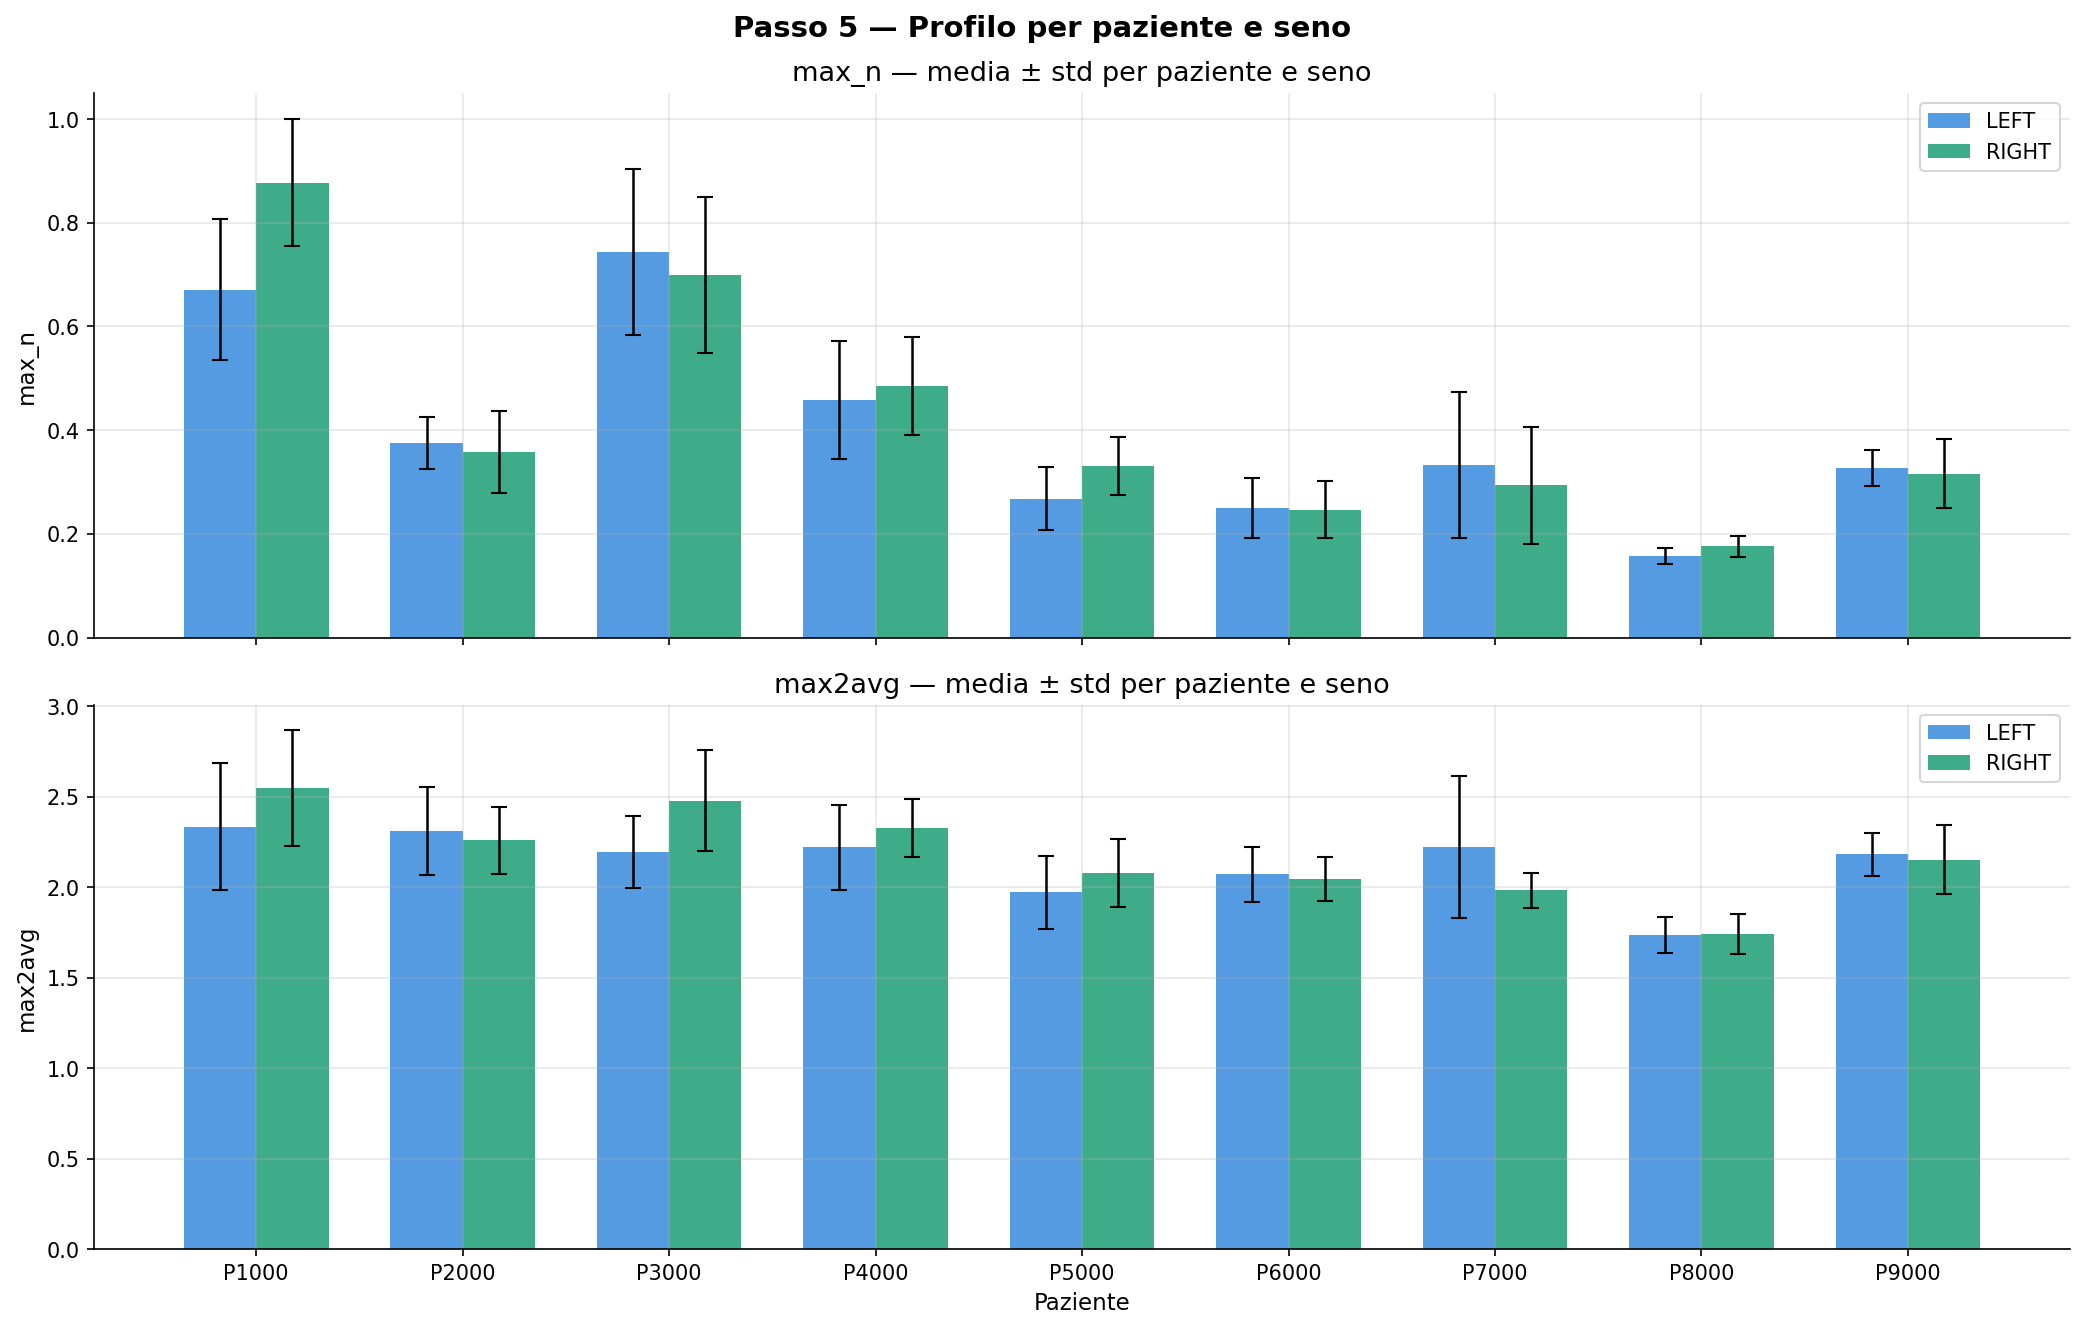

💾 Salvato: passo5_profilo_paziente_seno.png


In [ ]:
# ── GRAFICO: profilo per paziente e seno — max_n e max2avg ────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

xs     = np.arange(len(patients))
w      = 0.35
labels_x = [f'P{p}' for p in patients]

for ax_i, metric in enumerate(['max_n', 'max2avg']):
    vals_l = [df_profile[(df_profile['Paziente']==p)&(df_profile['Seno']=='LEFT')][f'{metric}_mean'].values[0]
              for p in patients]
    vals_r = [df_profile[(df_profile['Paziente']==p)&(df_profile['Seno']=='RIGHT')][f'{metric}_mean'].values[0]
              for p in patients]
    err_l  = [df_profile[(df_profile['Paziente']==p)&(df_profile['Seno']=='LEFT')][f'{metric}_std'].values[0]
              for p in patients]
    err_r  = [df_profile[(df_profile['Paziente']==p)&(df_profile['Seno']=='RIGHT')][f'{metric}_std'].values[0]
              for p in patients]

    axes[ax_i].bar(xs - w/2, vals_l, w, label='LEFT',  color='#378ADD', alpha=0.85,
                   yerr=err_l, capsize=4, error_kw={'linewidth':1.2})
    axes[ax_i].bar(xs + w/2, vals_r, w, label='RIGHT', color='#1D9E75', alpha=0.85,
                   yerr=err_r, capsize=4, error_kw={'linewidth':1.2})
    axes[ax_i].set_title(f"{metric} — media ± std per paziente e seno")
    axes[ax_i].set_ylabel(metric)
    axes[ax_i].legend()

axes[1].set_xticks(xs)
axes[1].set_xticklabels(labels_x)
axes[1].set_xlabel("Paziente")
plt.suptitle("Passo 5 — Profilo per paziente e seno", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/passo5_profilo_paziente_seno.png")
plt.show()
print("💾 Salvato: passo5_profilo_paziente_seno.png")

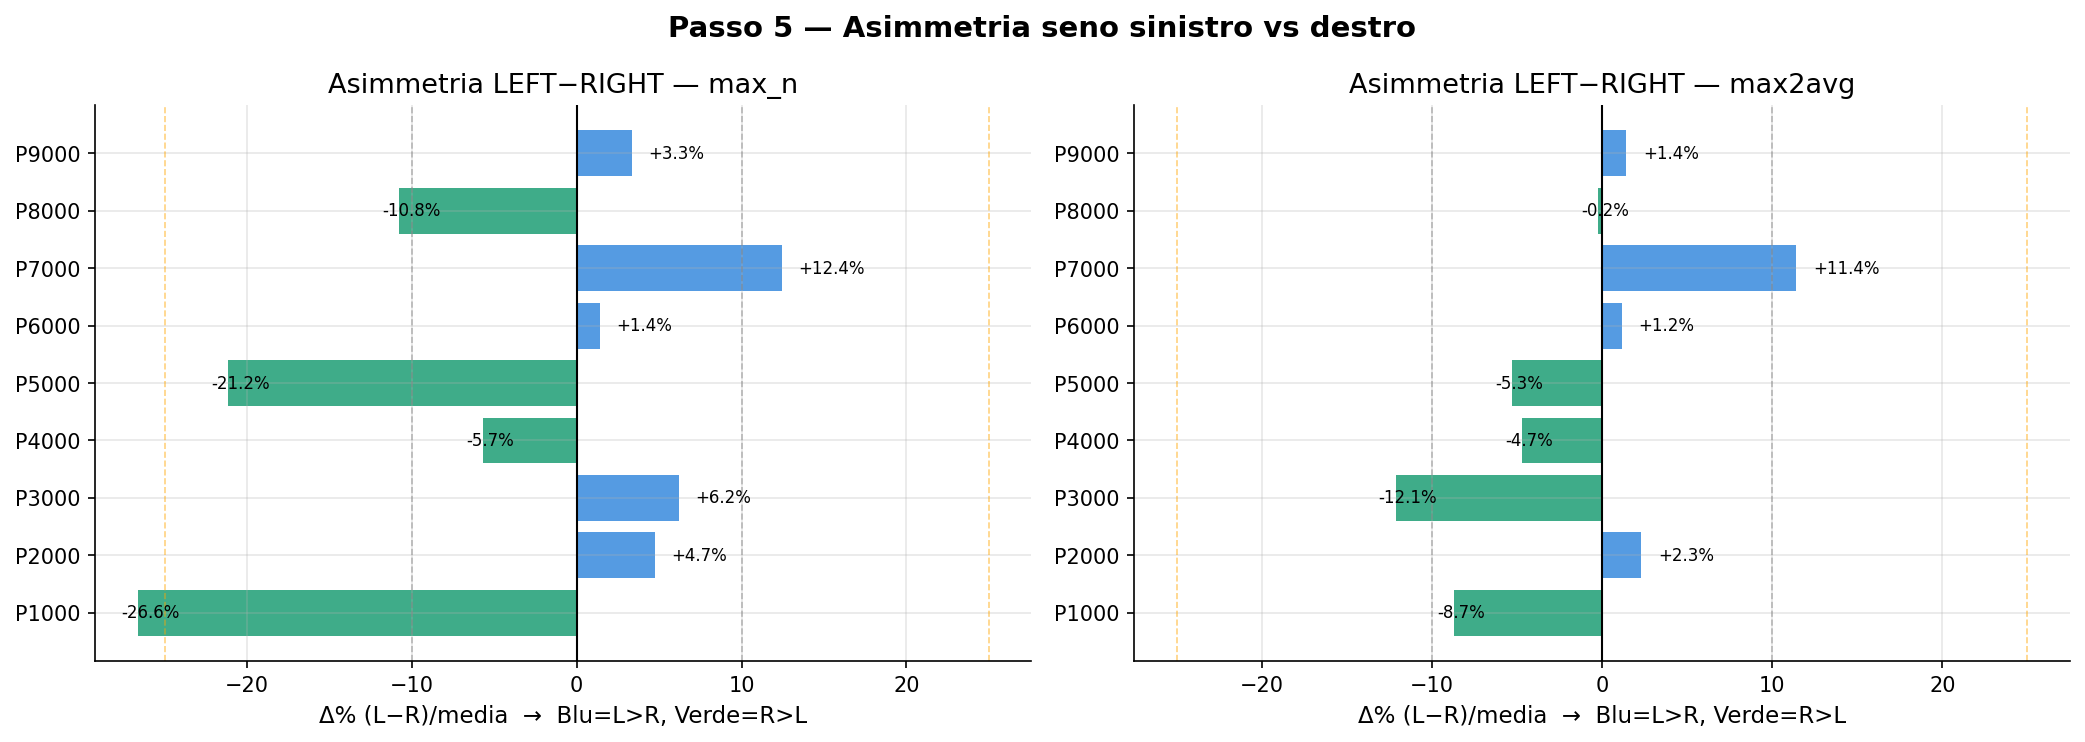

💾 Salvato: passo5_asimmetria_lr.png


In [ ]:
# ── GRAFICO: asimmetria LEFT vs RIGHT ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_i, metric in enumerate(['max_n', 'max2avg']):
    deltas  = df_asym[f'{metric}_delta%'].values
    pat_lbl = [f'P{p}' for p in df_asym['Paziente'].values]
    bar_col = ['#378ADD' if d > 0 else '#1D9E75' for d in deltas]
    axes[ax_i].barh(pat_lbl, deltas, color=bar_col, alpha=0.85)
    axes[ax_i].axvline(0, color='black', linewidth=1)
    axes[ax_i].axvline(10,  color='gray',   linestyle='--', linewidth=0.8, alpha=0.5)
    axes[ax_i].axvline(-10, color='gray',   linestyle='--', linewidth=0.8, alpha=0.5)
    axes[ax_i].axvline(25,  color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[ax_i].axvline(-25, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[ax_i].set_title(f"Asimmetria LEFT−RIGHT — {metric}")
    axes[ax_i].set_xlabel("Δ% (L−R)/media  →  Blu=L>R, Verde=R>L")
    for bar, v in zip(axes[ax_i].patches, deltas):
        axes[ax_i].text(v + (1 if v>=0 else -1), bar.get_y()+bar.get_height()/2,
                        f'{v:+.1f}%', va='center', fontsize=8)

plt.suptitle("Passo 5 — Asimmetria seno sinistro vs destro", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/passo5_asimmetria_lr.png")
plt.show()
print("💾 Salvato: passo5_asimmetria_lr.png")

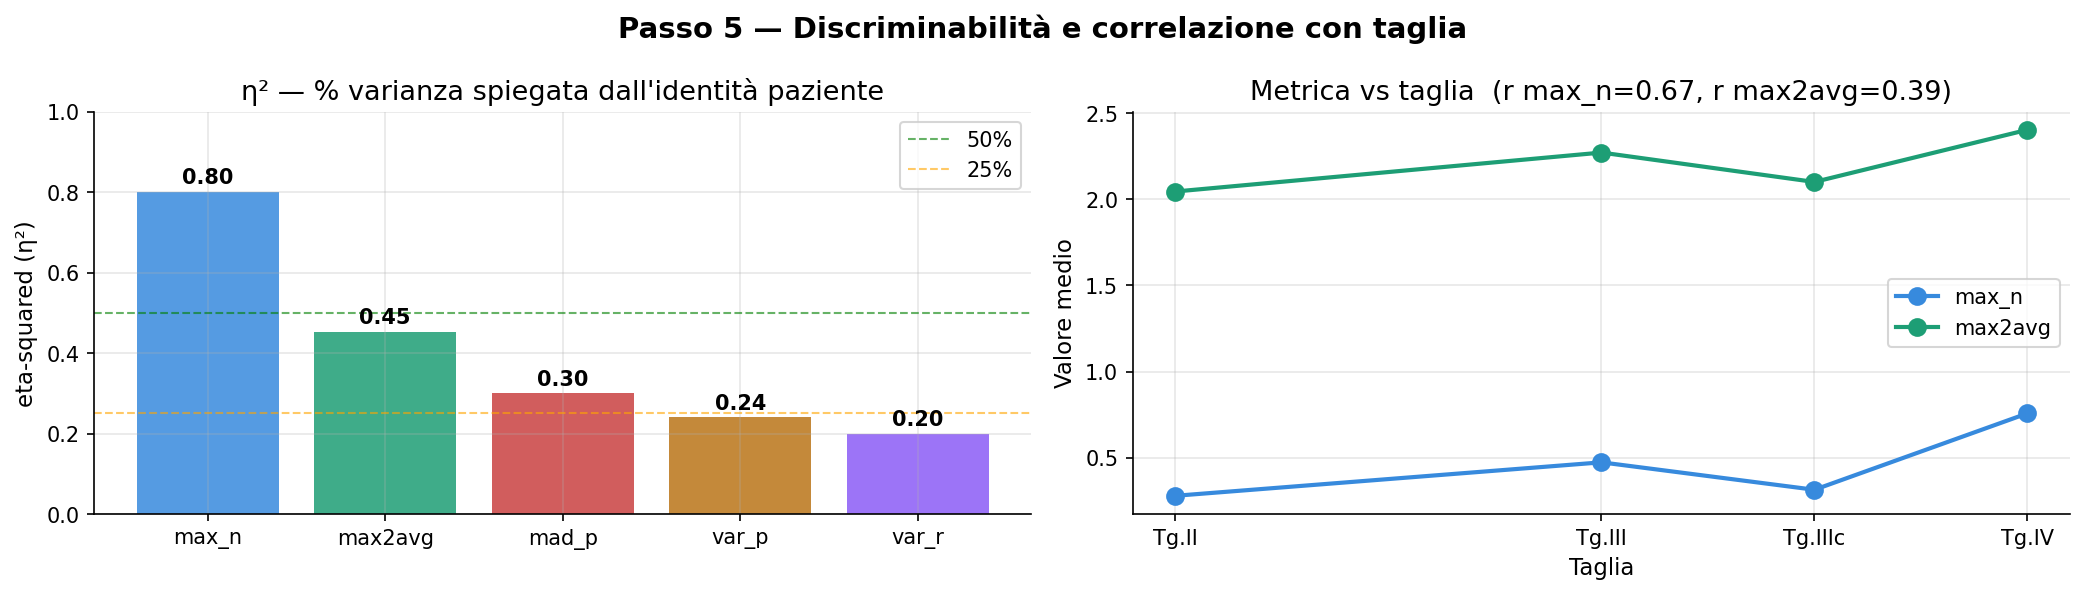

💾 Salvato: passo5_eta2_taglia.png


In [ ]:
# ── GRAFICO: eta² — capacità discriminante ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

eta2_vals   = df_eta2['η²'].values
metric_lbls = df_eta2['Metrica'].values
bar_cols_e  = [colors_m.get(m,'#888') for m in metric_lbls]

bars = axes[0].bar(metric_lbls, eta2_vals, color=bar_cols_e, alpha=0.85)
axes[0].axhline(0.50, color='green',  linestyle='--', linewidth=1, alpha=0.6, label='50%')
axes[0].axhline(0.25, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='25%')
axes[0].set_title("η² — % varianza spiegata dall'identità paziente")
axes[0].set_ylabel("eta-squared (η²)")
axes[0].set_ylim(0, 1.0)
axes[0].legend()
for bar, v in zip(bars, eta2_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Correlazione taglia vs max_n
df['taglia_num'] = df['Mis_norm'].map(taglia_map)
for m, col in [('max_n','#378ADD'),('max2avg','#1D9E75')]:
    mn_by_tag = df.groupby('taglia_num')[m].mean()
    axes[1].plot(mn_by_tag.index, mn_by_tag.values, 'o-', color=col, label=m,
                 linewidth=2, markersize=8)

r_mn, p_mn   = stats.spearmanr(df['taglia_num'], df['max_n'])
r_m2, p_m2   = stats.spearmanr(df['taglia_num'], df['max2avg'])
axes[1].set_xticks([2, 3, 3.5, 4])
axes[1].set_xticklabels(['Tg.II','Tg.III','Tg.IIIc','Tg.IV'])
axes[1].set_title(f"Metrica vs taglia  (r max_n={r_mn:.2f}, r max2avg={r_m2:.2f})")
axes[1].set_xlabel("Taglia")
axes[1].set_ylabel("Valore medio")
axes[1].legend()

plt.suptitle("Passo 5 — Discriminabilità e correlazione con taglia", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/passo5_eta2_taglia.png")
plt.show()
print("💾 Salvato: passo5_eta2_taglia.png")

## 7. Analisi dedicata max2avg (metrica prioritaria)
`max2avg` è la metrica più stabile per follow-up: quasi insensibile al riposizionamento.

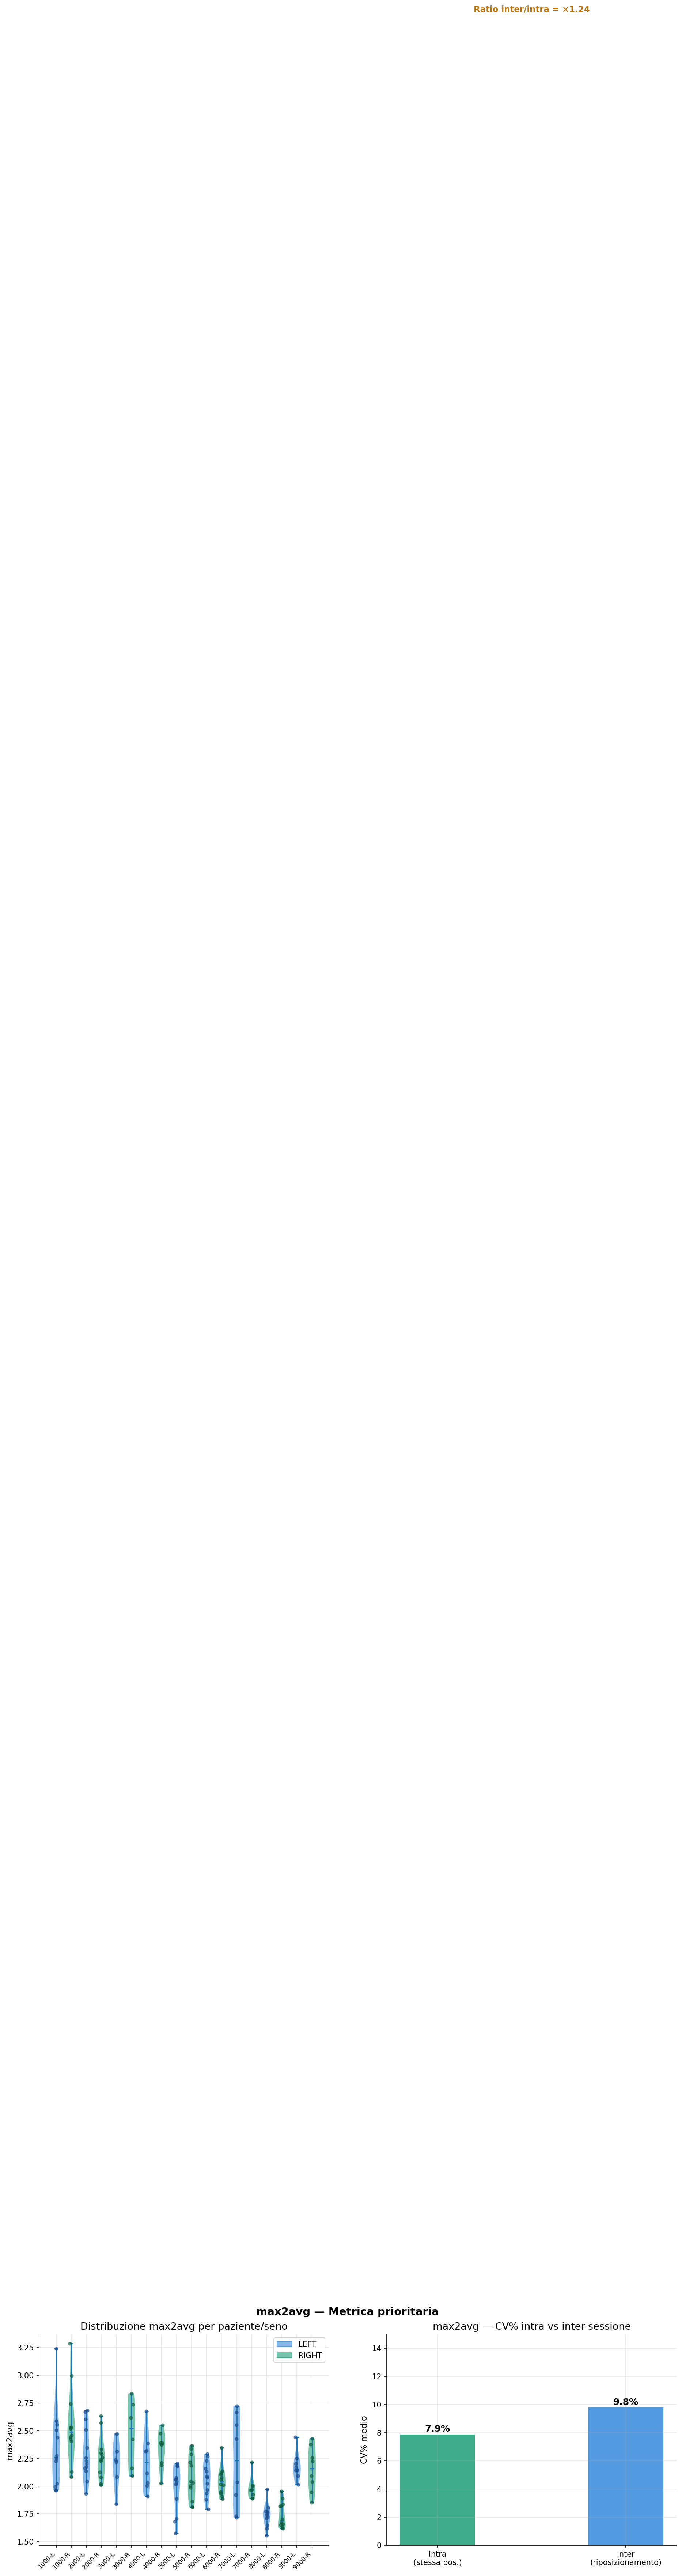

💾 Salvato: max2avg_analisi_dedicata2.png


In [36]:
# ── DISTRIBUZIONE max2avg PER PAZIENTE/SENO ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Violin + strip plot
import warnings; warnings.filterwarnings('ignore')
df['pat_breast'] = df['Patient'].astype(str) + '-' + df['Breast'].str[0]
order_ = [f'{p}-{s}' for p in sorted(df['Patient'].unique()) for s in ['L','R']]

ax = axes[0]
parts = ax.violinplot([df[df['pat_breast']==pb]['max2avg'].values for pb in order_],
                       positions=range(len(order_)), showmedians=True)
for i, (pc, pb) in enumerate(zip(parts['bodies'], order_)):
    pc.set_facecolor('#378ADD' if pb.endswith('-L') else '#1D9E75')
    pc.set_alpha(0.6)
    # strip
    y = df[df['pat_breast']==pb]['max2avg'].values
    x = np.random.normal(i, 0.05, size=len(y))
    ax.scatter(x, y, alpha=0.6, s=15,
               color='#1a4a8a' if pb.endswith('-L') else '#0a5a3a', zorder=3)
ax.set_xticks(range(len(order_)))
ax.set_xticklabels(order_, rotation=45, ha='right', fontsize=8)
ax.set_title("Distribuzione max2avg per paziente/seno")
ax.set_ylabel("max2avg")
patch_l = mpatches.Patch(color='#378ADD', alpha=0.6, label='LEFT')
patch_r = mpatches.Patch(color='#1D9E75', alpha=0.6, label='RIGHT')
ax.legend(handles=[patch_l, patch_r])

# CV% intra vs inter per max2avg
cv_intra_m2 = pairs['max2avg_cv'].mean()
cv_inter_m2 = inter_clean['max2avg_icv'].mean()
bars_m2 = axes[1].bar(['Intra\n(stessa pos.)', 'Inter\n(riposizionamento)'],
                        [cv_intra_m2, cv_inter_m2],
                        color=['#1D9E75','#378ADD'], alpha=0.85, width=0.4)
axes[1].set_title("max2avg — CV% intra vs inter-sessione")
axes[1].set_ylabel("CV% medio")
axes[1].set_ylim(0, 15)
for bar, v in zip(bars_m2, [cv_intra_m2, cv_inter_m2]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}%',
                 ha='center', fontweight='bold', fontsize=12)
axes[1].text(0.5, 12, f'Ratio inter/intra = ×{cv_inter_m2/cv_intra_m2:.2f}',
             ha='center', transform=axes[1].transAxes,
             fontsize=11, color='#BA7517', fontweight='bold')

plt.suptitle("max2avg — Metrica prioritaria", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/max2avg_analisi_dedicata2.png")
plt.show()
print("💾 Salvato: max2avg_analisi_dedicata2.png")

## 8. Grafici multi-metrica per paziente e seno
Asse X = Paziente-Seno, Asse Y = valore delle metriche (normalizzato e assoluto).

In [ ]:
# ── PREPARAZIONE DATI ─────────────────────────────────────────────────────
pb_order = [f'P{p}-{s}' for p in sorted(df['Patient'].unique())
            for s in ['LEFT','RIGHT']]
pb_short  = [f'P{p}-{"L" if s=="LEFT" else "R"}' for p in sorted(df['Patient'].unique())
             for s in ['LEFT','RIGHT']]

raw_vals  = {}
norm_vals = {}
for m in METRICS:
    vals = []
    for p in sorted(df['Patient'].unique()):
        for s in ['LEFT','RIGHT']:
            sub = df[(df['Patient']==p)&(df['Breast']==s)]
            vals.append(sub[m].mean() if len(sub)>0 else np.nan)
    raw_vals[m] = np.array(vals)
    mn_, mx_ = np.nanmin(vals), np.nanmax(vals)
    norm_vals[m] = np.array([(v-mn_)/(mx_-mn_) if not np.isnan(v) else np.nan for v in vals])

print(f"✅ Dati preparati per {len(pb_order)} combinazioni paziente/seno")

✅ Dati preparati per 18 combinazioni paziente/seno


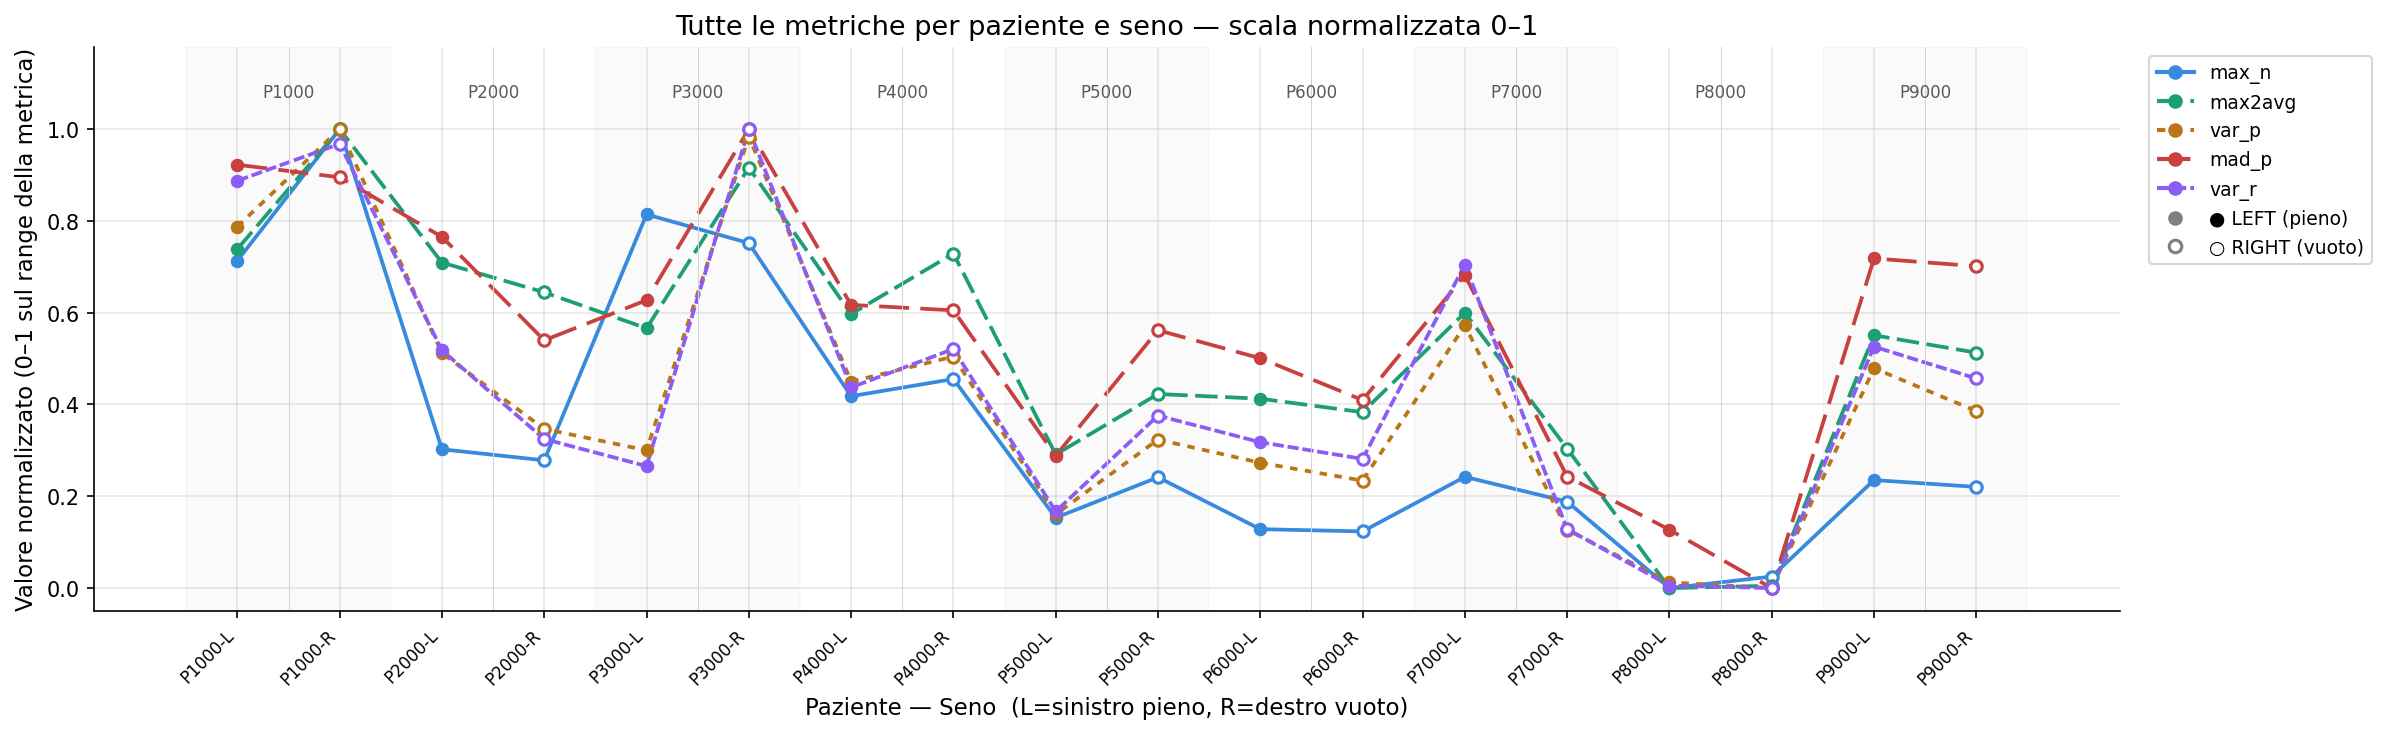

💾 Salvato: multiplot_normalizzato.png


In [31]:
# ── GRAFICO 1: Vista normalizzata (0–1) — tutte le metriche ───────────────
colors_m = {'max_n':'#378ADD','max2avg':'#1D9E75','var_p':'#BA7517',
            'mad_p':'#c94040','var_r':'#8b5cf6'}
dashes_m  = {'max_n':(1,0),'max2avg':(6,2),'var_p':(2,2),'mad_p':(8,3),'var_r':(3,1)}

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(pb_order))

for m in METRICS:
    col = colors_m[m]
    y   = norm_vals[m]

    # Traccia la linea completa
    ax.plot(x, y, '-', color=col, linewidth=1.8, dashes=dashes_m[m], zorder=2)

    # Punti LEFT: cerchio pieno; RIGHT: cerchio vuoto
    x_left  = [xi for xi, pb in zip(x, pb_order) if pb.endswith('-LEFT')]
    y_left  = [y[xi] for xi, pb in zip(x, pb_order) if pb.endswith('-LEFT')]
    x_right = [xi for xi, pb in zip(x, pb_order) if pb.endswith('-RIGHT')]
    y_right = [y[xi] for xi, pb in zip(x, pb_order) if pb.endswith('-RIGHT')]

    ax.scatter(x_left,  y_left,  s=30, color=col,    zorder=3, label=f'{m} (L)')
    ax.scatter(x_right, y_right, s=30, facecolors='white',
               edgecolors=col, linewidths=1.5, zorder=3)

# Sfumatura di sfondo per gruppi paziente
for i, p in enumerate(sorted(df['Patient'].unique())):
    x0, x1 = i*2 - 0.5, i*2 + 1.5
    ax.axvspan(x0, x1, alpha=0.04 if i%2==0 else 0.0, color='gray')
    ax.text(i*2 + 0.5, 1.07, f'P{p}', ha='center', fontsize=8, color='#595959')

ax.set_xticks(x)
ax.set_xticklabels(pb_short, rotation=45, ha='right', fontsize=8)
ax.set_xlabel("Paziente — Seno  (L=sinistro pieno, R=destro vuoto)")
ax.set_ylabel("Valore normalizzato (0–1 sul range della metrica)")
ax.set_title("Tutte le metriche per paziente e seno — scala normalizzata 0–1")
ax.set_ylim(-0.05, 1.18)

# Legenda pulita: una voce per metrica
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors_m[m], linewidth=2,
           marker='o', markersize=6, label=m,
           dashes=dashes_m[m] if dashes_m[m] != (1,0) else (None,None))
    for m in METRICS
]
legend_elements += [
    Line2D([0], [0], marker='o', color='gray', markersize=6,
           label='● LEFT (pieno)', linestyle='None'),
    Line2D([0], [0], marker='o', color='gray', markersize=6,
           markerfacecolor='white', markeredgewidth=1.5,
           label='○ RIGHT (vuoto)', linestyle='None'),
]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Separatori verticali tra LEFT e RIGHT
for xi, pb in enumerate(pb_order):
    if pb.endswith('-LEFT'):
        ax.axvline(xi + 0.5, color='lightgray', linewidth=0.5)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/multiplot_normalizzato.png")
plt.show()
print("💾 Salvato: multiplot_normalizzato.png")

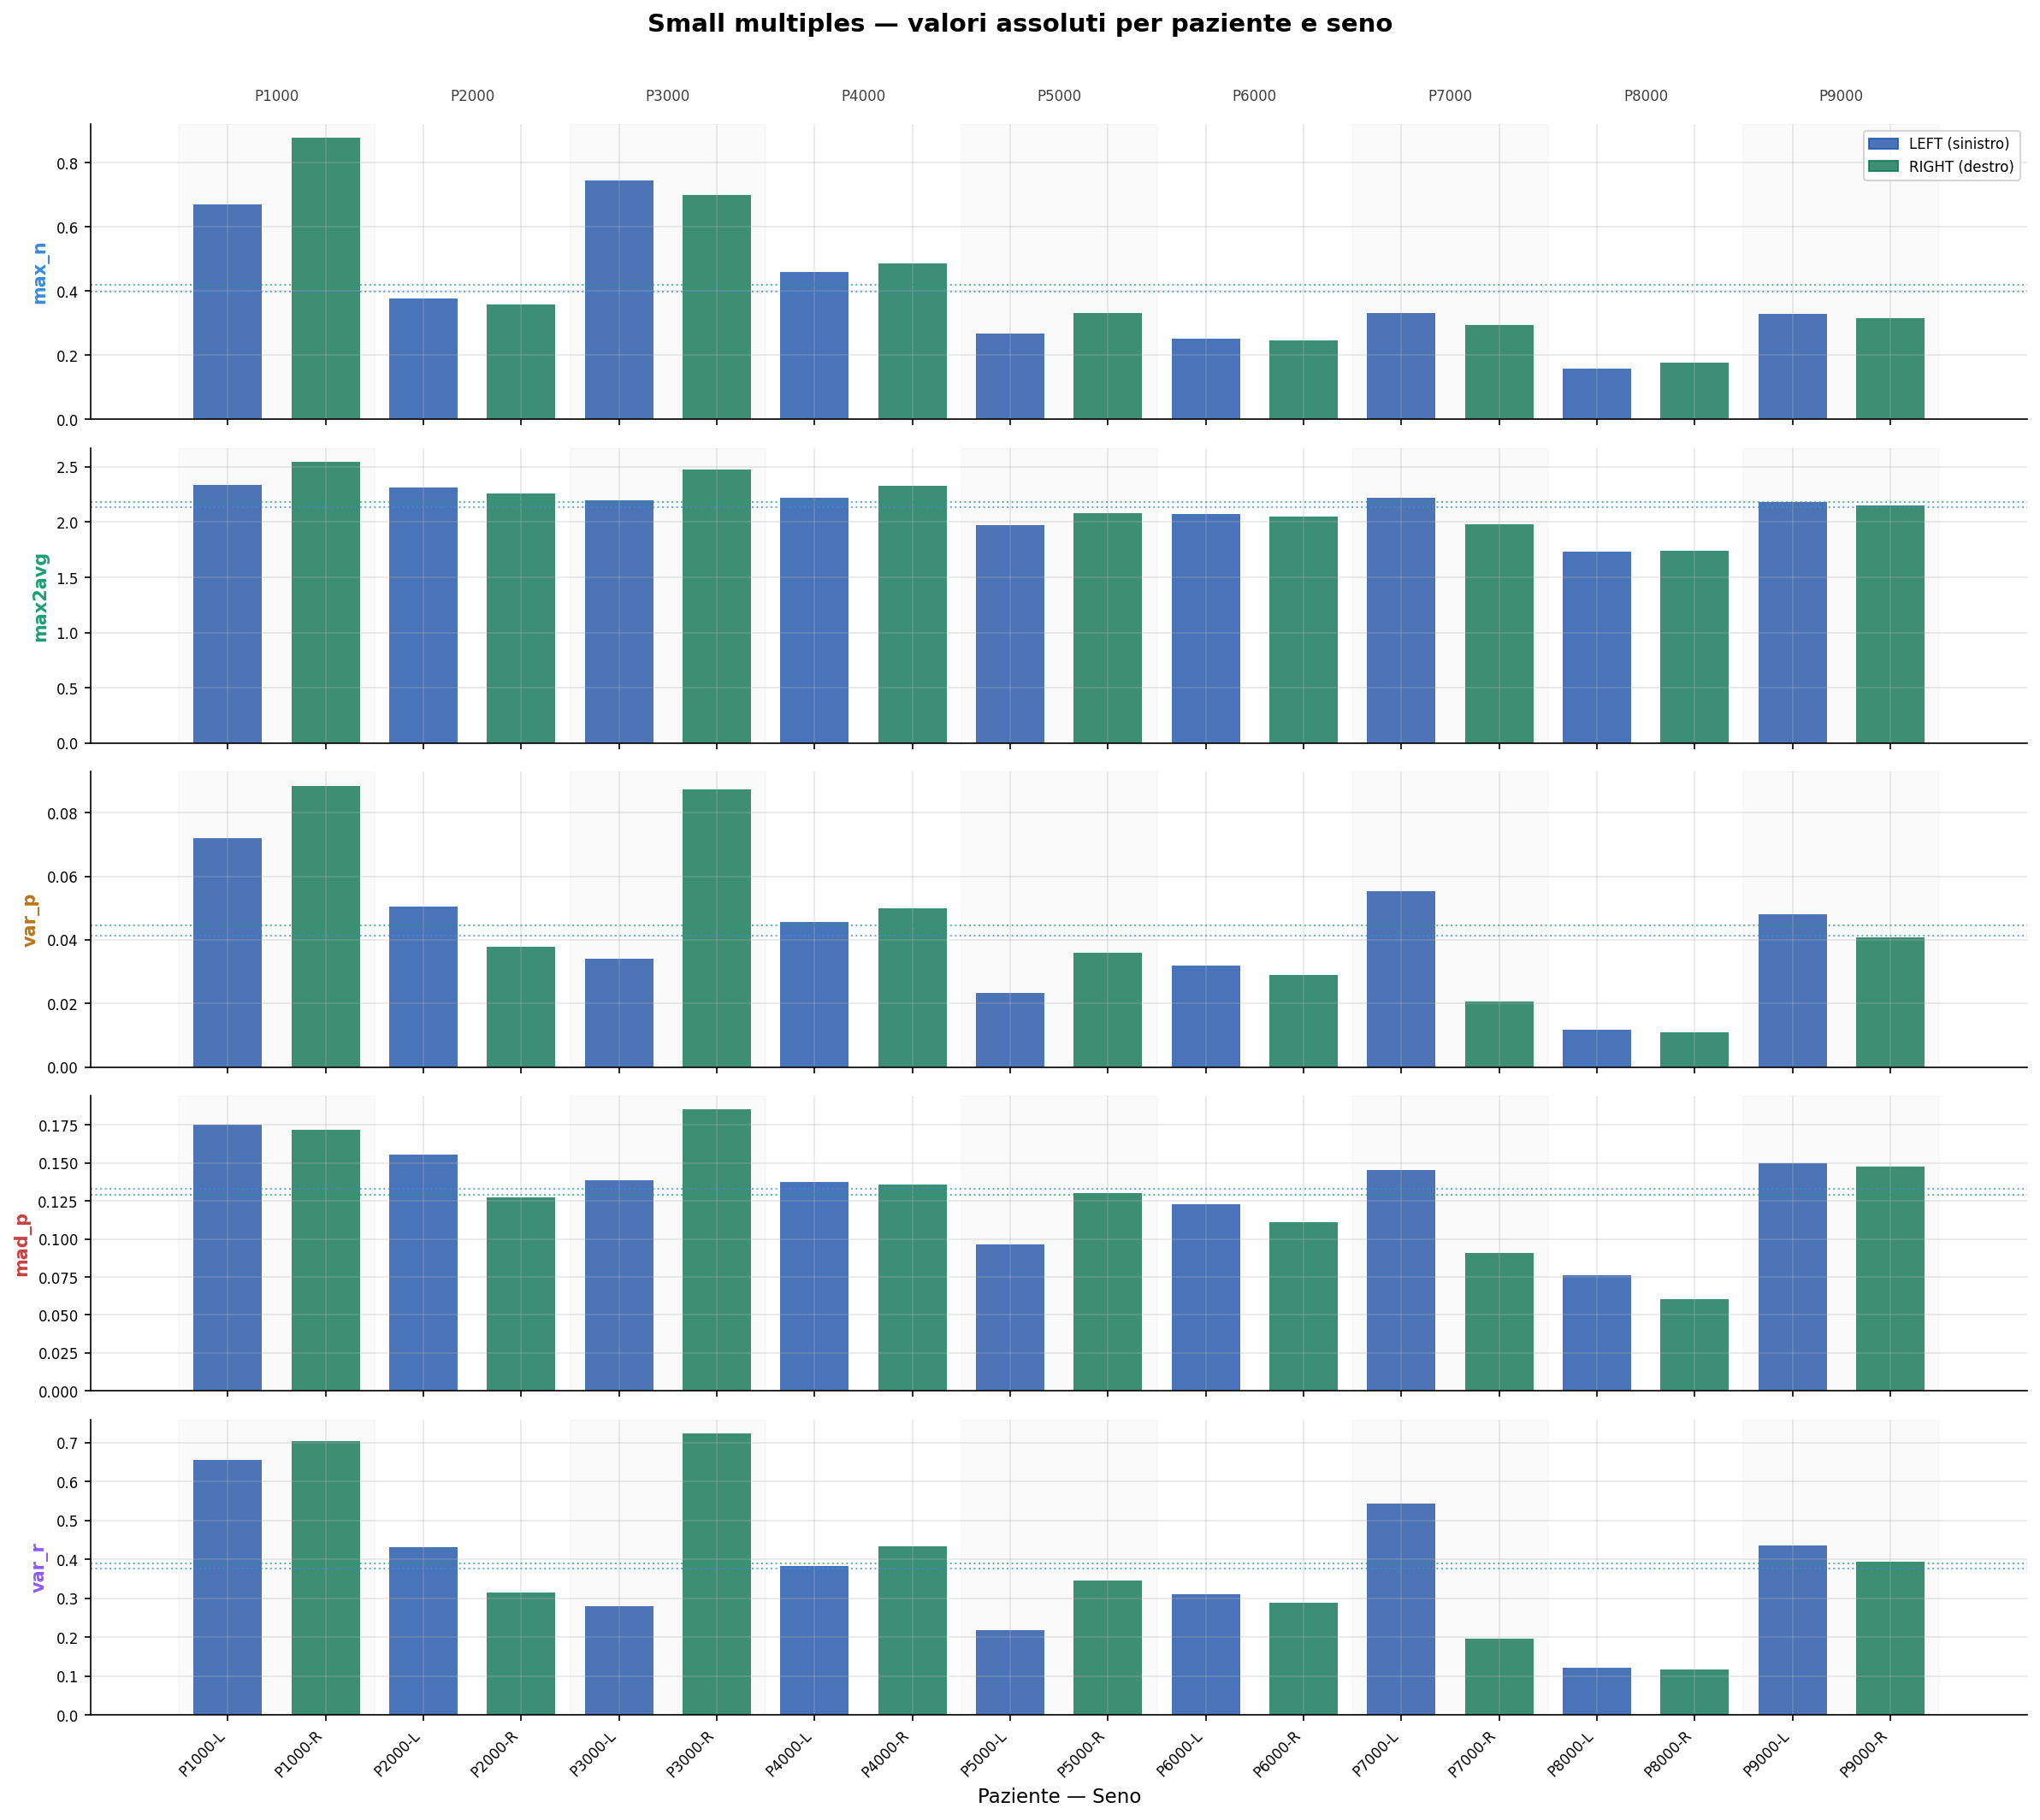

💾 Salvato: multiplot_small_multiples.png


In [32]:
# ── GRAFICO 2: Small multiples — valori assoluti ──────────────────────────
fig, axes = plt.subplots(len(METRICS), 1, figsize=(16, 14), sharex=True)

x = np.arange(len(pb_order))
bar_colors = ['#2255AA' if pb.endswith('-LEFT') else '#117755' for pb in pb_order]

for ax_i, m in enumerate(METRICS):
    axes[ax_i].bar(x, raw_vals[m], color=bar_colors, alpha=0.82, width=0.7)
    axes[ax_i].set_ylabel(m, fontsize=10, fontweight='bold', color=colors_m[m])
    axes[ax_i].tick_params(axis='y', labelsize=8)
    # Media per seno
    mn_l = np.nanmean([raw_vals[m][i] for i,pb in enumerate(pb_order) if pb.endswith('-LEFT')])
    mn_r = np.nanmean([raw_vals[m][i] for i,pb in enumerate(pb_order) if pb.endswith('-RIGHT')])
    axes[ax_i].axhline(mn_l, color='#378ADD', linestyle=':', linewidth=1, alpha=0.7)
    axes[ax_i].axhline(mn_r, color='#1D9E75', linestyle=':', linewidth=1, alpha=0.7)
    # Sfondo pazienti
    for pi in range(len(patients)):
        if pi % 2 == 0:
            axes[ax_i].axvspan(pi*2-0.5, pi*2+1.5, alpha=0.04, color='gray')

    if ax_i == 0:
        patch_l = mpatches.Patch(color='#2255AA', alpha=0.82, label='LEFT (sinistro)')
        patch_r = mpatches.Patch(color='#117755', alpha=0.82, label='RIGHT (destro)')
        axes[ax_i].legend(handles=[patch_l, patch_r], fontsize=8, loc='upper right')

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(pb_short, rotation=45, ha='right', fontsize=8)
axes[-1].set_xlabel("Paziente — Seno")

# Etichette pazienti in cima
for i, p in enumerate(sorted(df['Patient'].unique())):
    axes[0].text(i*2 + 0.5, axes[0].get_ylim()[1]*1.08, f'P{p}',
                 ha='center', fontsize=8, color='#404040')

plt.suptitle("Small multiples — valori assoluti per paziente e seno", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/multiplot_small_multiples.png")
plt.show()
print("💾 Salvato: multiplot_small_multiples.png")

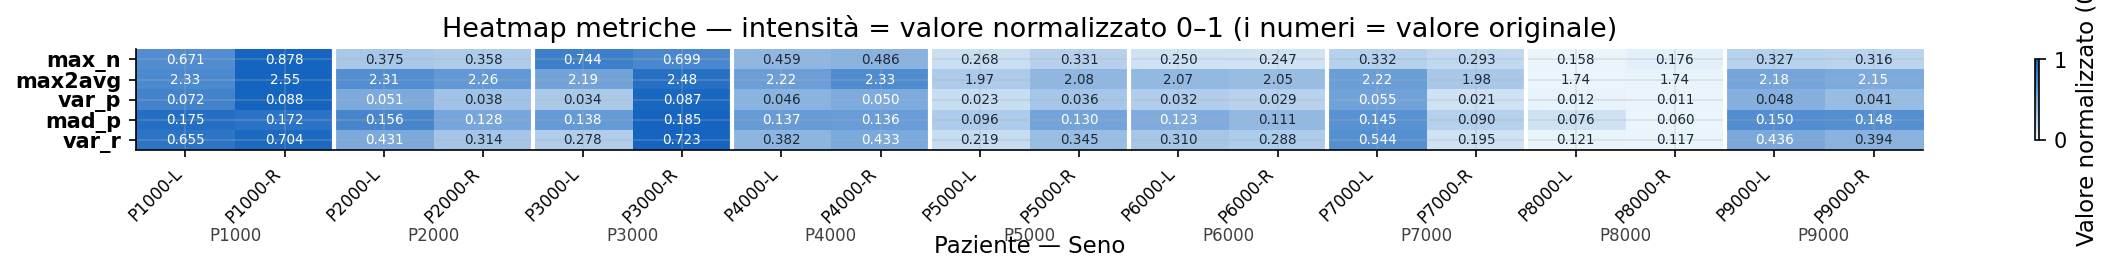

💾 Salvato: multiplot_heatmap.png


In [33]:
# ── GRAFICO 3: Heatmap ────────────────────────────────────────────────────
heat_matrix = np.array([norm_vals[m] for m in METRICS])

fig, ax = plt.subplots(figsize=(16, 4))
cmap = LinearSegmentedColormap.from_list('mammo', ['#eaf4fb','#1565c0'])
im = ax.imshow(heat_matrix, aspect='auto', cmap=cmap, vmin=0, vmax=1)

# Valori nelle celle
for ri in range(len(METRICS)):
    for ci in range(len(pb_order)):
        v_raw  = raw_vals[METRICS[ri]][ci]
        v_norm = heat_matrix[ri, ci]
        txt    = f'{v_raw:.3f}' if v_raw < 1 else f'{v_raw:.2f}'
        col    = 'white' if v_norm > 0.5 else '#1a2a3a'
        ax.text(ci, ri, txt, ha='center', va='center', fontsize=6.5,
                color=col, fontweight='normal')

ax.set_xticks(range(len(pb_short)))
ax.set_xticklabels(pb_short, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(METRICS)))
ax.set_yticklabels(METRICS, fontsize=10, fontweight='bold')
ax.set_xlabel("Paziente — Seno")
ax.set_title("Heatmap metriche — intensità = valore normalizzato 0–1 (i numeri = valore originale)")

# Separatori verticali per paziente
for i in range(1, len(patients)):
    ax.axvline(i*2 - 0.5, color='white', linewidth=2)
# Etichette pazienti
for i, p in enumerate(sorted(df['Patient'].unique())):
    ax.text(i*2 + 0.5, -0.9, f'P{p}', ha='center', fontsize=8, color='#404040',
            transform=ax.get_xaxis_transform())

plt.colorbar(im, ax=ax, label='Valore normalizzato (0–1)', shrink=0.8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/multiplot_heatmap.png")
plt.show()
print("💾 Salvato: multiplot_heatmap.png")

## 9. Export report completo su Google Drive
Salvataggio di tutti i risultati in un file Excel multi-foglio.

In [34]:
# ── EXPORT EXCEL MULTI-FOGLIO ─────────────────────────────────────────────
output_excel = f"{OUTPUT_DIR}/MAMMOWAVE_Report_Completo.xlsx"

with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:

    # Foglio 0: Dati grezzi puliti
    df.drop(columns=['pat_breast','taglia_num'], errors='ignore').to_excel(
        writer, sheet_name='0_Dati_puliti', index=False)

    # Foglio 1: Coppie intra
    pairs.to_excel(writer, sheet_name='1_Coppie_intra_CV', index=False)

    # Foglio 2: Intra globale
    df_intra.to_excel(writer, sheet_name='2_Intra_globale', index=False)

    # Foglio 3: Intra per paziente
    pat_intra_rows = []
    for pat in sorted(pairs['Patient'].unique()):
        for breast in ['LEFT','RIGHT','TOTALE']:
            sub = pairs[pairs['Patient']==pat] if breast=='TOTALE'                   else pairs[(pairs['Patient']==pat)&(pairs['Breast']==breast)]
            if len(sub)==0: continue
            row = {'Paziente':pat,'Seno':breast,'N':len(sub),'Taglia':sub['Mis_norm'].iloc[0]}
            for m in METRICS:
                row[f'{m}_mean_acq']  = round(sub[f'{m}_mean'].mean(), 4)
                row[f'{m}_CV%_intra'] = round(sub[f'{m}_cv'].mean(), 2)
            pat_intra_rows.append(row)
    pd.DataFrame(pat_intra_rows).to_excel(writer, sheet_name='3_Intra_per_paziente', index=False)

    # Foglio 4: Inter-sessione
    inter_clean.to_excel(writer, sheet_name='4_Inter_sessione', index=False)
    df_inter.to_excel(writer, sheet_name='4b_Inter_riepilogo', index=False)

    # Foglio 5: Effetto coppa
    df_cup.to_excel(writer, sheet_name='5_Effetto_coppa', index=False)

    # Foglio 6: Discriminabilità
    df_eta2.to_excel(writer, sheet_name='6_Discriminabilita', index=False)

    # Foglio 7: Profilo paziente/seno
    df_profile.to_excel(writer, sheet_name='7_Profilo_paziente_seno', index=False)

    # Foglio 8: Asimmetria
    df_asym.to_excel(writer, sheet_name='8_Asimmetria_LR', index=False)

    # Foglio 9: Riepilogo pazienti
    df_summary.to_excel(writer, sheet_name='9_Riepilogo_pazienti', index=False)

print(f"✅ Report Excel salvato: {output_excel}")

✅ Report Excel salvato: /content/drive/MyDrive/data/rep/output/MAMMOWAVE_Report_Completo.xlsx


In [35]:
# ── RIEPILOGO FILE SALVATI ────────────────────────────────────────────────
import os
saved_files = sorted([f for f in os.listdir(OUTPUT_DIR)
                      if f.endswith(('.png','.csv','.xlsx'))])
print(f"\n📁 File salvati in {OUTPUT_DIR}:")
print(f"{'─'*55}")
total_size = 0
for f in saved_files:
    size = os.path.getsize(f"{OUTPUT_DIR}/{f}") / 1024
    total_size += size
    icon = '📊' if f.endswith('.xlsx') else '🖼️ ' if f.endswith('.png') else '📄'
    print(f"  {icon}  {f:<45} {size:>6.1f} KB")
print(f"{'─'*55}")
print(f"  Totale: {total_size:.1f} KB  ({len(saved_files)} file)")


📁 File salvati in /content/drive/MyDrive/data/rep/output:
───────────────────────────────────────────────────────
  📊  MAMMOWAVE_Report_Completo.xlsx                  79.9 KB
  🖼️   max2avg_analisi_dedicata.png                   214.5 KB
  🖼️   multiplot_heatmap.png                          120.2 KB
  🖼️   multiplot_normalizzato.png                     248.2 KB
  🖼️   multiplot_small_multiples.png                  157.7 KB
  🖼️   passo1_struttura_dataset.png                    61.8 KB
  🖼️   passo2_cv_per_paziente.png                      80.5 KB
  🖼️   passo2_intra_cv_icc.png                         91.2 KB
  📄  passo2_intra_globale.csv                         0.3 KB
  🖼️   passo3_inter_sessione.png                       88.7 KB
  📄  passo3_inter_vs_intra.csv                        0.2 KB
  📄  passo4_effetto_coppa.csv                         1.0 KB
  🖼️   passo4_effetto_coppa.png                       106.2 KB
  🖼️   passo4_within_patient_cup.png                   95.5 KB
  📄  passo5